# 🧠 ML Theory & Statistics Questions — Explain *Why*, Not Just *How*

> **What you'll practise:** 107 conceptual interview questions across probability & statistics, linear algebra, ML fundamentals, classical models, deep learning, NLP & LLMs, recommendation systems, causal inference, and MLOps — each with a 30-second answer, a "go deeper" layer, and the most common wrong answer — plus 15 runnable demonstrations that turn claims ("p-values are uniform under the null", "L1 zeroes coefficients") into numbers you computed yourself, and 3 rapid-fire rounds.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~8–10 hours over 1–2 weeks (about 5 minutes per question answered out loud) + 3 × 10-minute rapid-fire rounds |
| **Prerequisites** | [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) · [Math for ML](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) · [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) · [Neural Networks From Scratch](../04_Deep_Learning/01_Neural_Networks_From_Scratch.ipynb) · [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) · [ML Coding Drills](01_ML_Coding_Drills.ipynb) |
| **Tested with** | Python 3.12 · numpy 2.5 · scipy 1.18 · statsmodels 0.15 · scikit-learn 1.9 · torch 2.14 · pandas 3.0 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ Very high — phone screens and "ML breadth / depth" rounds for ML engineer, data scientist, applied scientist, and AI engineer roles; the same concepts come back as follow-ups in coding and system-design rounds |

## 🎯 How This Round Works

A **theory screen** checks whether you understand the ideas behind the tools. It rarely involves code; it involves explaining, a little whiteboard math, and reasoning about trade-offs.

### Two styles of questioning

| Style | What it looks like | How to answer |
|---|---|---|
| **Rapid-fire (breadth)** | 20–40 short questions in 30–45 minutes: "What's a p-value?", "L1 vs L2?", "Why √d_k?" | One or two crisp sentences, then stop. Let the interviewer ask for more. |
| **Depth-probing (drill-down)** | Starts broad — "How does gradient boosting work?" — then keeps asking *why* until you reach your limit | Answer in layers: definition → intuition → math → trade-offs. Each follow-up goes one layer deeper. |
| **Whiteboard math** | "Derive the gradient of logistic regression", "apply Bayes' theorem to this test", "what's the MLE of p?" | Write the setup, state assumptions, go step by step, and sanity-check the result with a number. |
| **Scenario** | "AUC dropped last week — what happened?", "your A/B test is significant after 2 days — ship it?" | Clarify, list hypotheses from most to least likely, say how you'd check each. |

### What interviewers evaluate

| Signal | Strong | Weak |
|---|---|---|
| **Precision** | Correct definitions with the right conditions ("*assuming the null is true*…") | Near-miss definitions (the #1 p-value mistake) |
| **Intuition** | A plain-English picture or example | Only formulas, or only hand-waving |
| **Math when asked** | Can derive or at least write the key formula | Freezes when asked "why?" |
| **Trade-offs & failure modes** | "It breaks when… so in practice I…" | Presents every method as universally good |
| **Connection to practice** | Links the concept to a real decision (threshold, metric, experiment design) | Textbook-only |
| **Honesty** | Says where their knowledge ends, then reasons | Bluffs confidently |

### How to recover when you don't know

1. **Say what you *do* know** that's adjacent: "I haven't used ALiBi, but I know attention needs position information because it's permutation-equivariant…"
2. **Reason from first principles out loud** — interviewers often care more about the reasoning than the fact.
3. **Work a tiny example** (two classes, three data points, a 2×2 matrix).
4. **State an assumption and continue:** "Assuming the samples are independent…"
5. **Never bluff.** A wrong confident answer costs more than "I'm not sure — here's how I'd find out."

### How to use this notebook

- Read a question, **answer out loud in under 60 seconds**, then open the answer and compare. Mark it ✅ (nailed it), 🟡 (partly), or ❌ (missed) in your own notes and revisit the 🟡/❌ ones in a few days.
- Run every **🔬 Demo** cell and explain its output as if the interviewer asked "can you show me?". The numbers are computed live — they will be the same every run because every demo is seeded.
- The **✍️ Your Turn** cells are short calculations interviewers ask you to do on a whiteboard: ⏳ = not attempted, ❌ = wrong (with a hint), ✅ = correct.

| Section | Questions | Demos |
|---|---|---|
| [1. Probability & Statistics 🟢](#1.-Probability-&-Statistics-🟢) | Q1–Q18 | p-values under the null · CLT · CI coverage · peeking · power |
| [2. Linear Algebra & Calculus for ML 🟡](#2.-Linear-Algebra-&-Calculus-for-ML-🟡) | Q19–Q28 | — |
| [3. ML Fundamentals 🟡](#3.-ML-Fundamentals-🟡) | Q29–Q42 | bias–variance · L1 vs L2 · leakage · imbalance · curse of dimensionality |
| [4. Classical Models 🟡](#4.-Classical-Models-🟡) | Q43–Q55 | — |
| [5. Deep Learning 🔴](#5.-Deep-Learning-🔴) | Q56–Q71 | vanishing gradients · attention scaling |
| [6. NLP & LLMs 🔴](#6.-NLP-&-LLMs-🔴) | Q72–Q86 | softmax temperature |
| [7. Recommendation & Ranking 🟡](#7.-Recommendation-&-Ranking-🟡) | Q87–Q93 | — |
| [8. Causal Inference 🔴](#8.-Causal-Inference-🔴) | Q94–Q99 | confounding & Simpson's paradox |
| [9. MLOps Concepts 🟡](#9.-MLOps-Concepts-🟡) | Q100–Q107 | drift tests at scale |
| [🏋️ Timed Drills](#🏋️-Timed-Drills) · [📋 Answer Framework & Cheat Sheet](#📋-Answer-Framework-&-Cheat-Sheet) · [📚 Resources](#📚-Resources) | Q108–Q137 (rapid-fire) | — |

## ⚙️ Setup

Run this cell first. If a package is missing, uncomment the `%pip` line, run it once, and restart the kernel.

The `check()` helper gives instant feedback on the ✍️ Your Turn calculations: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "numpy>=2.0" "scipy>=1.13" "statsmodels>=0.14" "scikit-learn>=1.5" "torch>=2.4" pandas matplotlib

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import torch
from scipy import stats

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | SciPy {scipy.__version__} | statsmodels {statsmodels.__version__} | "
      f"scikit-learn {sklearn.__version__} | PyTorch {torch.__version__}")

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.grid": True, "grid.alpha": 0.3})


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got), np.asarray(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    ok = np.allclose(got_arr, exp_arr) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | SciPy 1.18.1 | statsmodels 0.15.0 | scikit-learn 1.9.1 | PyTorch 2.14.0


## 1. Probability & Statistics 🟢

> 📖 **Review:** [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) — Bayes' theorem, distributions, the CLT, confidence intervals, hypothesis tests, power, multiple testing, MLE, and A/B testing.

Statistics questions appear in almost every data-science screen and in many ML-engineer screens, because experiments (A/B tests) and model evaluation are statistics. The most common failure is an *almost right* definition — so pay attention to the exact wording.

**Q1. A disease affects 1% of people. A test has 99% sensitivity and 95% specificity. You test positive. What's the probability you have the disease?**

<details><summary>Show answer</summary>

- **30-second answer:** About **17%**. Bayes: $P(D \mid +) = \frac{P(+ \mid D)P(D)}{P(+ \mid D)P(D) + P(+ \mid \neg D)P(\neg D)} = \frac{0.99 \cdot 0.01}{0.99 \cdot 0.01 + 0.05 \cdot 0.99} = \frac{1}{6}$. Because the disease is rare, false positives from the 99% healthy people outnumber the true positives.
- **Go deeper:** Think in counts: of 10,000 people, 100 are sick (99 test positive) and 9,900 are healthy (495 test positive) → 99 / 594 ≈ 16.7%. This base-rate effect is why fraud and anomaly detectors with "99% accuracy" still flood analysts with false alarms, and why screening is followed by a more specific second test.
- **❌ Common wrong answer:** "99%" — confusing $P(+ \mid D)$ with $P(D \mid +)$ (the "prosecutor's fallacy").

</details>

### ✍️ Your Turn — Bayes on a whiteboard

Compute `posterior` = P(disease | positive test) for prevalence 1%, sensitivity 99%, specificity 95%. Use only arithmetic.

In [2]:
prevalence, sensitivity, specificity = 0.01, 0.99, 0.95
posterior = None  # TODO: P(disease | positive)
check("posterior", posterior, 1 / 6, hint="true positives / (true positives + false positives); P(+ | healthy) = 1 − specificity.")

⏳ posterior: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
prevalence, sensitivity, specificity = 0.01, 0.99, 0.95
true_positive_rate_overall = sensitivity * prevalence                   # P(+ and sick)
false_positive_rate_overall = (1 - specificity) * (1 - prevalence)      # P(+ and healthy)
posterior = true_positive_rate_overall / (true_positive_rate_overall + false_positive_rate_overall)
check("posterior", posterior, 1 / 6)
```
</details>

**Q2. Are mutually exclusive events independent?**

<details><summary>Show answer</summary>

- **30-second answer:** No — if two events with non-zero probability are mutually exclusive, they are strongly *dependent*: knowing one happened tells you the other didn't. Independence means $P(A \cap B) = P(A)\,P(B)$; mutual exclusivity means $P(A \cap B) = 0$.
- **Go deeper:** Both hold only in the degenerate case where one event has probability 0. Independence is about information ("does knowing A change my belief about B?"), not about overlap.
- **❌ Common wrong answer:** "Yes, they don't affect each other because they can't happen together."

</details>

**Q3. Which probability distributions come up most in ML work, and where?**

<details><summary>Show answer</summary>

- **30-second answer:** **Bernoulli/Binomial** — clicks, conversions, correct/incorrect; **Categorical/Multinomial** — class labels and next-token prediction; **Poisson** — counts per time interval (requests per second; mean = variance); **Exponential** — waiting times between events; **Normal** — measurement noise and sample means (via the CLT); **Beta** — uncertainty about a probability (the conjugate prior of the Binomial); **Log-normal / heavy-tailed** — incomes, latencies, prices.
- **Go deeper:** Knowing the distribution picks the loss: Gaussian noise ↔ MSE, Bernoulli ↔ binary cross-entropy, Categorical ↔ cross-entropy, Poisson ↔ Poisson deviance. Heavy tails mean the mean is dominated by rare extremes — report medians and p95/p99 for latencies.
- **❌ Common wrong answer:** "Assume everything is normal" — counts, rates, and latencies usually aren't.

</details>

**Q4. State the Central Limit Theorem. What does it *not* say?**

<details><summary>Show answer</summary>

- **30-second answer:** For i.i.d. samples from a distribution with finite mean μ and finite variance σ², the distribution of the **sample mean** approaches a normal distribution with mean μ and standard deviation σ/√n as n grows — whatever the shape of the original distribution. It does *not* say the data itself becomes normal.
- **Go deeper:** How fast depends on skewness: the skewness of a mean of n exponential samples is 2/√n (demo below), so strongly skewed data needs a larger n than the folklore "n = 30". Distributions without finite variance (e.g. Cauchy) break the theorem. The CLT is why z/t-tests and normal-approximation confidence intervals work for means and proportions.
- **❌ Common wrong answer:** "With a big enough sample, the data becomes normally distributed" or "n ≥ 30 is always enough."

</details>

### 🔬 Demo: the CLT in action — means of a skewed distribution

The exponential distribution is very right-skewed (skewness 2). Theory says the mean of n samples has skewness 2/√n. Let's check.

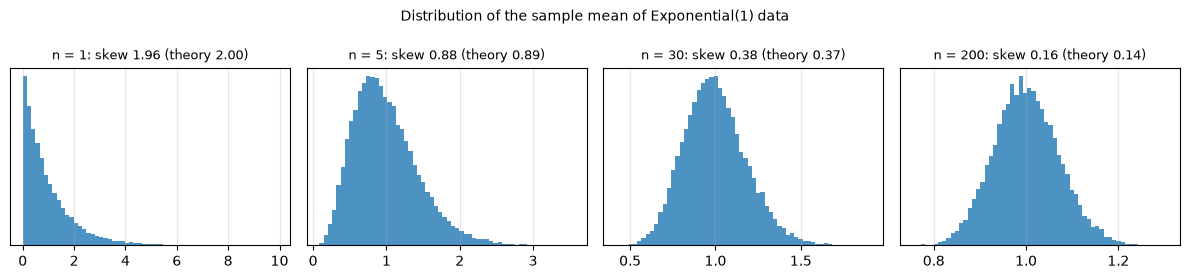

In [3]:
clt_rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, n in zip(axes, (1, 5, 30, 200)):
    means = clt_rng.exponential(scale=1.0, size=(20_000, n)).mean(axis=1)
    ax.hist(means, bins=60, density=True, color="tab:blue", alpha=0.8)
    ax.set_title(f"n = {n}: skew {stats.skew(means):.2f} (theory {2 / np.sqrt(n):.2f})", fontsize=9)
    ax.set_yticks([])
fig.suptitle("Distribution of the sample mean of Exponential(1) data", fontsize=10)
plt.tight_layout()
plt.show()

**Q5. What's the difference between the law of large numbers and the CLT?**

<details><summary>Show answer</summary>

- **30-second answer:** The law of large numbers says the sample mean **converges** to the true mean as n grows. The CLT describes the **shape and size of the remaining error** for a finite n: approximately normal with standard deviation σ/√n.
- **Go deeper:** LLN justifies Monte Carlo estimates and "averaging over many users"; the CLT tells you how many samples you need for a given precision — to halve the error you need 4× the data.
- **❌ Common wrong answer:** "They're the same theorem."

</details>

**Q6. What exactly is a p-value?**

<details><summary>Show answer</summary>

- **30-second answer:** The probability of observing a test statistic at least as extreme as the one you got, **assuming the null hypothesis (and the test's assumptions) are true**. A small p-value means the data would be surprising if there were no effect.
- **Go deeper:** It is not the probability that the null is true, not the probability the result is a fluke, and not a measure of effect size — with enough data, trivial effects get tiny p-values. When the null is true and the test statistic is continuous, p-values are **uniformly distributed** on [0, 1], so a 0.05 threshold gives a 5% false-positive rate — the demo below shows this.
- **❌ Common wrong answer:** "p = 0.03 means there's a 3% chance the null hypothesis is true."

</details>

### 🔬 Demo: p-values are uniform when the null is true — and multiple testing

We run 20,000 **A/A tests** (both groups drawn from the same distribution, so the null is true), then group the p-values into "studies" of 20 metrics each to see what happens when you test many things at once.

share of A/A tests with p < 0.05: 0.047  (theory: 0.050)
KS test of the p-values against Uniform(0, 1): p = 0.30 → consistent with uniform
studies with ≥1 'significant' metric out of 20: 0.605  (theory 1 − 0.95²⁰ = 0.642; with this sample's per-test rate: 1 − (1 − 0.047)²⁰ = 0.617)
... after Bonferroni (α / 20): 0.044


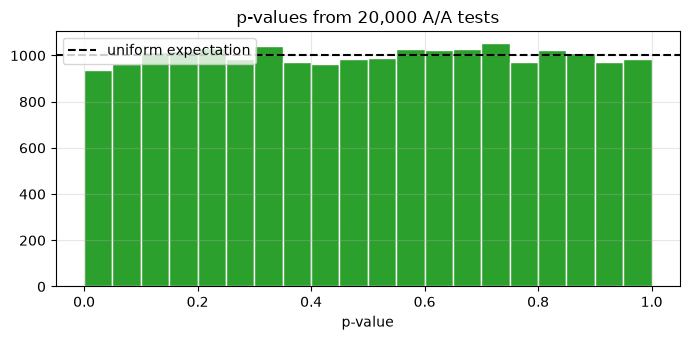

In [4]:
pval_rng = np.random.default_rng(42)
group_a = pval_rng.normal(size=(20_000, 30))
group_b = pval_rng.normal(size=(20_000, 30))                       # same distribution → no real difference
p_values = stats.ttest_ind(group_a, group_b, axis=1).pvalue

false_positive_rate = (p_values < 0.05).mean()
ks_p = stats.kstest(p_values, "uniform").pvalue
studies = p_values.reshape(1000, 20)                                # 1,000 "studies", 20 metrics each
any_false_positive = (studies < 0.05).any(axis=1).mean()
any_after_bonferroni = (studies < 0.05 / 20).any(axis=1).mean()

print(f"share of A/A tests with p < 0.05: {false_positive_rate:.3f}  (theory: 0.050)")
print(f"KS test of the p-values against Uniform(0, 1): p = {ks_p:.2f} → "
      f"{'consistent with uniform' if ks_p > 0.05 else 'NOT uniform'}")
print(f"studies with ≥1 'significant' metric out of 20: {any_false_positive:.3f}  (theory 1 − 0.95²⁰ = {1 - 0.95 ** 20:.3f}; "
      f"with this sample's per-test rate: 1 − (1 − {false_positive_rate:.3f})²⁰ = {1 - (1 - false_positive_rate) ** 20:.3f})")
print(f"... after Bonferroni (α / 20): {any_after_bonferroni:.3f}")

plt.hist(p_values, bins=20, range=(0, 1), color="tab:green", edgecolor="white")
plt.axhline(len(p_values) / 20, color="black", linestyle="--", label="uniform expectation")
plt.title("p-values from 20,000 A/A tests")
plt.xlabel("p-value")
plt.legend()
plt.tight_layout()
plt.show()

**Q7. Define Type I error, Type II error, significance level, and power.**

<details><summary>Show answer</summary>

- **30-second answer:** A **Type I error** is a false positive (rejecting a true null); its probability is the significance level α. A **Type II error** is a false negative (missing a real effect); its probability is β. **Power** = 1 − β = the probability of detecting an effect of a given size when it really exists.
- **Go deeper:** Power increases with the true effect size, the sample size, and α, and decreases with noise (variance). Underpowered studies not only miss effects — the "significant" results they do find overestimate the effect size (the winner's curse).
- **❌ Common wrong answer:** "Power is the probability that the null hypothesis is false."

</details>

**Q8. How do you interpret a 95% confidence interval?**

<details><summary>Show answer</summary>

- **30-second answer:** It's the output of a procedure that, over many repeated samples, produces intervals containing the true parameter 95% of the time. Any single computed interval either contains the true value or doesn't; the 95% describes the method.
- **Go deeper:** A Bayesian **credible interval** is the one that allows "95% probability the parameter is in here" (given the prior). For small samples, use the t distribution — the demo shows z-based intervals with n = 5 under-cover. Wider intervals come from more noise, smaller n, or higher confidence.
- **❌ Common wrong answer:** "There's a 95% probability that the true mean lies in this particular interval."

</details>

### 🔬 Demo: what "95% confidence" means — coverage over repeated samples

In [5]:
ci_rng = np.random.default_rng(7)
true_mean = 10.0
for n in (25, 5):
    samples = ci_rng.normal(true_mean, 3.0, size=(10_000, n))
    means, sems = samples.mean(axis=1), samples.std(axis=1, ddof=1) / np.sqrt(n)
    t_crit, z_crit = stats.t.ppf(0.975, df=n - 1), stats.norm.ppf(0.975)
    t_cover = np.mean(np.abs(means - true_mean) <= t_crit * sems)
    z_cover = np.mean(np.abs(means - true_mean) <= z_crit * sems)
    print(f"n = {n:2d}: t-interval covers the true mean in {t_cover:.3f} of samples | "
          f"z-interval (1.96·SE) covers {z_cover:.3f}")

n = 25: t-interval covers the true mean in 0.948 of samples | z-interval (1.96·SE) covers 0.935
n =  5: t-interval covers the true mean in 0.949 of samples | z-interval (1.96·SE) covers 0.874


**Q9. What's the difference between standard deviation and standard error?**

<details><summary>Show answer</summary>

- **30-second answer:** The **standard deviation** describes how spread out individual data points are. The **standard error** describes how uncertain an *estimate* is — for a mean, SE = σ/√n. More data doesn't change the SD, but it shrinks the SE.
- **Go deeper:** Error bars must say which one they show: ±1 SD shows variability between users; ±1 SE (or a 95% CI ≈ ±1.96 SE) shows uncertainty about the average. For a proportion, SE = √(p(1 − p)/n).
- **❌ Common wrong answer:** "They're the same; SE is just what statisticians call SD."

</details>

**Q10. How do you decide the sample size for an A/B test?**

<details><summary>Show answer</summary>

- **30-second answer:** Before the test, choose α (e.g. 0.05), power (e.g. 0.8), the baseline rate, and the **minimum detectable effect** (MDE) that matters to the business, then solve for n. For two proportions: $n \approx \frac{(z_{1-\alpha/2} + z_{1-\beta})^2\,[p_1(1-p_1) + p_2(1-p_2)]}{(p_1 - p_2)^2}$ per group — detecting 10% → 12% needs roughly 3,800–3,850 users per arm (computed below).
- **Go deeper:** n scales with 1/MDE², so halving the detectable effect needs about 4× the users. Variance-reduction methods such as CUPED (adjusting for pre-experiment behaviour) cut the required sample size. Run for whole weeks to cover day-of-week patterns.
- **❌ Common wrong answer:** "Run the test until the result becomes significant."

</details>

### 🔬 Demo: sample size and power for 10% → 12% conversion

In [6]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

p1, p2, alpha, power = 0.10, 0.12, 0.05, 0.80
z_alpha, z_beta = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
n_formula = (z_alpha + z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2)) / (p2 - p1) ** 2
n_statsmodels = NormalIndPower().solve_power(effect_size=proportion_effectsize(p2, p1), alpha=alpha, power=power)
n_half_mde = NormalIndPower().solve_power(effect_size=proportion_effectsize(0.11, p1), alpha=alpha, power=power)
print(f"users per arm — formula: {np.ceil(n_formula):.0f} | statsmodels (Cohen's h): {np.ceil(n_statsmodels):.0f}")
print(f"halving the effect (10% → 11%) needs {np.ceil(n_half_mde):.0f} per arm = {n_half_mde / n_statsmodels:.1f}× more")

# check the power by simulation: run 4,000 experiments where the effect is real
power_rng = np.random.default_rng(3)
n_arm = int(np.ceil(n_statsmodels))
conv_a = power_rng.binomial(n_arm, p1, size=4000) / n_arm
conv_b = power_rng.binomial(n_arm, p2, size=4000) / n_arm
pooled = (conv_a + conv_b) / 2
z_scores = (conv_b - conv_a) / np.sqrt(pooled * (1 - pooled) * 2 / n_arm)
print(f"power estimated from 4,000 synthetic experiments at n = {n_arm}: {np.mean(np.abs(z_scores) > z_alpha):.3f} (target {power})")

users per arm — formula: 3839 | statsmodels (Cohen's h): 3835
halving the effect (10% → 11%) needs 14745 per arm = 3.8× more
power estimated from 4,000 synthetic experiments at n = 3835: 0.808 (target 0.8)


**Q11. Why is "peeking" at an A/B test and stopping when p < 0.05 a problem?**

<details><summary>Show answer</summary>

- **30-second answer:** Every look is another chance for random noise to cross the threshold, so stopping at the first significant look inflates the false-positive rate far above 5% — in the demo below, checking 20 times turns a 5% error rate into roughly 25%.
- **Go deeper:** If you need to monitor continuously, use a method designed for it: group-sequential designs with alpha spending (e.g. O'Brien–Fleming boundaries), always-valid p-values / mSPRT, or a pre-registered fixed horizon. Early stopping for *harm* on guardrail metrics is fine when planned.
- **❌ Common wrong answer:** "Looking at the data doesn't change it, so peeking is harmless."

</details>

### 🔬 Demo: peeking inflates false positives

2,000 A/A tests (both arms convert at 10%). "Fixed" analyses once at 2,000 users per arm; "peeking" checks after every 100 users and stops at the first p < 0.05.

In [7]:
peek_rng = np.random.default_rng(11)
n_sims, n_max = 2000, 2000
looks = np.arange(100, n_max + 1, 100)
arm_a = peek_rng.random((n_sims, n_max)) < 0.10
arm_b = peek_rng.random((n_sims, n_max)) < 0.10
conversions_a = arm_a.cumsum(axis=1)[:, looks - 1]
conversions_b = arm_b.cumsum(axis=1)[:, looks - 1]
pooled_rate = (conversions_a + conversions_b) / (2 * looks)
se = np.sqrt(pooled_rate * (1 - pooled_rate) * 2 / looks)
z = np.divide((conversions_b - conversions_a) / looks, se, out=np.zeros(se.shape), where=se > 0)
significant = np.abs(z) > stats.norm.ppf(0.975)
print(f"false-positive rate, one analysis at the end : {significant[:, -1].mean():.3f}")
print(f"false-positive rate, peeking {len(looks)} times        : {significant.any(axis=1).mean():.3f}")

false-positive rate, one analysis at the end : 0.050
false-positive rate, peeking 20 times        : 0.246


**Q12. You test 20 metrics in one experiment and 1 is significant at p < 0.05. What do you conclude?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably nothing yet. With 20 independent tests at α = 0.05 and no real effects, the chance of at least one false positive is 1 − 0.95²⁰ ≈ 64% (the p-value demo above lands close to this). Correct for multiple comparisons, or treat the finding as a hypothesis to confirm in a new experiment.
- **Go deeper:** **Bonferroni** (test each at α/m) controls the family-wise error rate but is conservative; **Benjamini–Hochberg** controls the false discovery rate (the expected share of false positives among discoveries) and keeps more power. Pre-registering one primary metric plus guardrails avoids the problem.
- **❌ Common wrong answer:** "It's significant, so that metric definitely moved."

</details>

**Q13. What are the most common pitfalls in A/B testing?**

<details><summary>Show answer</summary>

- **30-second answer:** Peeking; underpowered tests; testing many metrics or segments without correction; **sample ratio mismatch** (a 50/50 design that yields 52/48 signals broken assignment or logging — check with a chi-square test); novelty or primacy effects; running for less than full weekly cycles; and **interference** between users (network effects, shared inventory), which violates the independence assumption.
- **Go deeper:** Randomize and analyse at the same unit (if you randomize users but analyse page views, rows are correlated and the variance is underestimated — use the delta method or cluster-robust errors). Watch guardrail metrics (latency, revenue, unsubscribes) and check whether the effect is consistent across major segments before shipping.
- **❌ Common wrong answer:** "If p < 0.05, ship it."

</details>

**Q14. When do you use a t-test, a z-test, a chi-square test, or a Mann–Whitney U test?**

<details><summary>Show answer</summary>

- **30-second answer:** **t-test** — compare means when the variance is estimated from the data (Welch's version, which doesn't assume equal variances, is the safe default; paired t-test for before/after on the same units). **z-test** — proportions or means with large samples. **Chi-square** — association between categorical variables or observed vs expected counts (e.g. sample ratio mismatch). **Mann–Whitney U** — a rank-based comparison when data is heavily skewed or ordinal.
- **Go deeper:** Mann–Whitney tests whether values from one group tend to be larger than the other's; it is a test of medians only when the two distributions have the same shape. For heavy-tailed revenue data, a bootstrap CI of the difference in means is often more useful than any single test.
- **❌ Common wrong answer:** "Always use Student's t-test with equal variances."

</details>

**Q15. What's the difference between MLE and MAP estimation?**

<details><summary>Show answer</summary>

- **30-second answer:** **MLE** picks the parameters that maximize the likelihood $P(\text{data} \mid \theta)$. **MAP** maximizes the posterior $P(\text{data} \mid \theta)\,P(\theta)$, i.e. it adds a log-prior term. A Gaussian prior on the weights gives L2 (ridge) regularization; a Laplace prior gives L1 (lasso).
- **Go deeper:** Example: 3 heads in 3 flips — the MLE is p = 1; with a Beta(2, 2) prior, MAP = (3 + 2 − 1)/(3 + 2 + 2 − 2) = 0.8. With lots of data the prior matters less and MAP → MLE. MAP is still a single point; a fully Bayesian approach keeps the whole posterior distribution.
- **❌ Common wrong answer:** "MAP is Bayesian, so it gives you uncertainty estimates."

</details>

**Q16. What are the maximum likelihood estimates for a Bernoulli and a Gaussian, and how does MLE connect to common losses?**

<details><summary>Show answer</summary>

- **30-second answer:** Bernoulli: $\hat p$ = the fraction of successes. Gaussian: $\hat\mu$ = the sample mean and $\hat\sigma^2 = \frac{1}{n}\sum (x_i - \bar x)^2$ (biased; dividing by n − 1 gives the unbiased estimate). Minimizing MSE is MLE under Gaussian noise; minimizing cross-entropy is MLE for a categorical output.
- **Go deeper:** Derivation pattern: write the log-likelihood, differentiate, set to zero. For the Bernoulli, $\ell(p) = k\log p + (n-k)\log(1-p)$, so $k/p - (n-k)/(1-p) = 0$ gives $p = k/n$. MLE is consistent and asymptotically efficient, but it can overfit small samples — the motivation for priors/regularization.
- **❌ Common wrong answer:** "The MLE of the variance divides by n − 1."

</details>

**Q17. What is the bootstrap, and when does it fail?**

<details><summary>Show answer</summary>

- **30-second answer:** Resample the dataset **with replacement** (same size n) many times, recompute the statistic each time, and use the spread of those values as its sampling distribution — giving standard errors and confidence intervals for almost any statistic (a median, an AUC, a difference in revenue).
- **Go deeper:** Each bootstrap sample contains on average 1 − 1/e ≈ 63.2% of the distinct original rows. It fails or needs care for very small samples, extreme statistics (the maximum), and dependent data (use a block bootstrap for time series, or resample whole users when rows are correlated). Random forests use the same idea (bagging) to build diverse trees.
- **❌ Common wrong answer:** "Bootstrapping creates new data, so it increases your sample size."

</details>

**Q18. Pearson vs Spearman correlation — and does zero correlation mean independence?**

<details><summary>Show answer</summary>

- **30-second answer:** Pearson measures **linear** association and is sensitive to outliers; Spearman is Pearson computed on ranks, so it captures any **monotonic** relationship and is robust to outliers. Zero correlation does **not** imply independence: y = x² with x symmetric around 0 has zero Pearson correlation but is completely dependent on x.
- **Go deeper:** Mutual information detects general dependence. Correlation also says nothing about causation (see section 8), and aggregated correlations can reverse within subgroups (Simpson's paradox).
- **❌ Common wrong answer:** "Correlation 0 means the variables are unrelated."

</details>

### ✍️ Your Turn — a confidence interval for a conversion rate

540 of 1,000 users converted. Compute the 95% **normal-approximation** (Wald) confidence interval as a tuple `(low, high)`: $\hat p \pm z_{0.975}\sqrt{\hat p(1-\hat p)/n}$. Use `stats.norm.ppf(0.975)` for z.

In [8]:
from statsmodels.stats.proportion import proportion_confint

successes, n_users = 540, 1000
wald_ci = None  # TODO: (low, high)
check("Wald 95% CI", wald_ci, proportion_confint(successes, n_users, alpha=0.05, method="normal"),
      hint="p_hat = 540 / 1000; se = sqrt(p_hat * (1 - p_hat) / n); p_hat ± 1.96 * se")

⏳ Wald 95% CI: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from statsmodels.stats.proportion import proportion_confint

successes, n_users = 540, 1000
p_hat = successes / n_users
se = np.sqrt(p_hat * (1 - p_hat) / n_users)
z_975 = stats.norm.ppf(0.975)
wald_ci = (p_hat - z_975 * se, p_hat + z_975 * se)
check("Wald 95% CI", wald_ci, proportion_confint(successes, n_users, alpha=0.05, method="normal"))
print(f"95% CI: [{wald_ci[0]:.4f}, {wald_ci[1]:.4f}]")
```

For small n or rates near 0 or 1, prefer the Wilson interval (`method="wilson"`): the Wald interval can extend below 0 and under-covers.
</details>

## 2. Linear Algebra & Calculus for ML 🟡

> 📖 **Review:** [Math for ML](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) — vectors, matrix multiplication, rank, eigenvalues, SVD, derivatives, the chain rule, gradients, convexity · [NumPy](../01_Core_Scientific_Computing/01_NumPy.ipynb) — `solve` vs `inv`

Interviewers rarely ask for proofs here. They ask whether you can connect a linear-algebra idea to something practical: PCA, embeddings, LoRA, conditioning, backprop.

**Q19. What does the dot product measure, and why is cosine similarity used for embeddings?**

<details><summary>Show answer</summary>

- **30-second answer:** $a \cdot b = \lVert a\rVert\,\lVert b\rVert \cos\theta$ — it grows when vectors point the same way and when they are long. Cosine similarity divides out the lengths, so it compares only direction, which is where embedding models put meaning.
- **Go deeper:** For unit-normalized vectors, dot product = cosine, and Euclidean distance is a monotonic function of it ($\lVert a - b\rVert^2 = 2 - 2\cos\theta$), so all three give the same ranking. The dot product is also a projection: $a \cdot \hat b$ is the length of a's shadow on b's direction.
- **❌ Common wrong answer:** "Cosine similarity is always better than dot product" — some retrieval models are trained with dot product and vector length carries signal.

</details>

**Q20. What are eigenvalues and eigenvectors, and where do they show up in ML?**

<details><summary>Show answer</summary>

- **30-second answer:** An eigenvector v of a square matrix A is a direction that A only stretches: $Av = \lambda v$, where λ is the stretch factor. In ML: PCA's components are eigenvectors of the covariance matrix; the Hessian's eigenvalues describe curvature (and limit the learning rate); the spectral radius of a recurrent weight matrix tells you whether RNN signals explode or vanish; spectral clustering and PageRank use eigenvectors of graph matrices.
- **Go deeper:** Symmetric matrices (like covariances) have real eigenvalues and orthogonal eigenvectors — use `np.linalg.eigh`. The ratio of the largest to smallest Hessian eigenvalue is the condition number that makes plain gradient descent zig-zag.
- **❌ Common wrong answer:** "Every matrix has real eigenvalues" — rotations don't, and non-square matrices have none (use SVD instead).

</details>

**Q21. What is the SVD, and name three ML uses.**

<details><summary>Show answer</summary>

- **30-second answer:** Every matrix factors as $A = U\Sigma V^\top$ — a rotation, an axis-aligned scaling by the singular values, and another rotation. Uses: PCA (on centered data), the best low-rank approximation (keeping the top k singular values is optimal — the Eckart–Young theorem), least squares / pseudo-inverse, matrix-factorization recommenders, and compressing weight matrices.
- **Go deeper:** Singular values tell you how much "energy" each rank-1 component carries; a fast decay means the matrix is approximately low-rank — the intuition behind LoRA adapters and embedding compression. Randomized SVD computes the top k components of huge matrices cheaply.
- **❌ Common wrong answer:** "SVD only works for square matrices."

</details>

**Q22. What is the rank of a matrix, and why do low-rank ideas matter in ML?**

<details><summary>Show answer</summary>

- **30-second answer:** Rank is the number of linearly independent columns (the dimension of the column space). If features are collinear or there are more features than samples, $X^\top X$ is rank-deficient and has no inverse — ordinary least squares has infinitely many solutions, so you regularize. Low-rank structure also lets you compress: LoRA learns $\Delta W = BA$ with rank r ≪ d.
- **Go deeper:** A d × d update of rank r needs only 2·d·r numbers instead of d²: for d = 4,096 and r = 8 that's 65,536 vs 16.8 million. Numerical rank (singular values above a tolerance) is what matters in floating point.
- **❌ Common wrong answer:** "Rank is the number of rows."

</details>

**Q23. What is a condition number, and why should an ML engineer care?**

<details><summary>Show answer</summary>

- **30-second answer:** The condition number κ = σ_max/σ_min measures how much a matrix can amplify relative errors. A large κ means tiny changes in the input produce big changes in the solution (unstable least squares) and an elongated loss surface where gradient descent zig-zags and converges slowly.
- **Go deeper:** Fixes: standardize features, remove or combine collinear ones, add ridge regularization (which raises the smallest eigenvalue by λ), use normalization layers or adaptive optimizers (a form of preconditioning), and never form $X^\top X$ when you can factor X — that squares κ.
- **❌ Common wrong answer:** "Use float64 and conditioning stops mattering."

</details>

**Q24. What is a positive semi-definite matrix, and where does it appear?**

<details><summary>Show answer</summary>

- **30-second answer:** A symmetric matrix A is PSD if $x^\top A x \ge 0$ for every x (equivalently, all eigenvalues ≥ 0). Covariance matrices and kernel (Gram) matrices are always PSD, and a twice-differentiable function is convex exactly when its Hessian is PSD everywhere.
- **Go deeper:** Positive definite (all eigenvalues > 0) guarantees a unique minimum of a quadratic and makes the Cholesky factorization possible — used to sample from multivariate Gaussians. A valid kernel for an SVM must produce PSD Gram matrices (Mercer's condition).
- **❌ Common wrong answer:** "PSD means all entries are positive."

</details>

**Q25. Gradient vs Jacobian vs Hessian?**

<details><summary>Show answer</summary>

- **30-second answer:** The **gradient** of a scalar function is the vector of partial derivatives (it points uphill). The **Jacobian** of a vector-valued function is the matrix of all first derivatives (m outputs × n inputs). The **Hessian** of a scalar function is the matrix of second derivatives, describing curvature.
- **Go deeper:** Backpropagation never builds full Jacobians; it computes vector–Jacobian products layer by layer, which is why it is cheap. The Hessian of a model with P parameters has P² entries — impossible to store for large networks, hence first-order optimizers and Hessian-vector-product tricks.
- **❌ Common wrong answer:** "The Hessian is just the gradient of the gradient, so computing it is as cheap as a gradient."

</details>

**Q26. How does backpropagation relate to the chain rule?**

<details><summary>Show answer</summary>

- **30-second answer:** Backpropagation is the chain rule applied efficiently from the loss backwards: each layer receives ∂L/∂(its output), multiplies by its local derivative, and passes ∂L/∂(its input) to the previous layer, reusing values stored during the forward pass. This is reverse-mode automatic differentiation.
- **Go deeper:** Reverse mode costs a small constant multiple of one forward pass no matter how many parameters there are, because the output (the loss) is a scalar. Forward-mode AD would need one pass per input direction. It is neither numerical differentiation (finite differences) nor symbolic differentiation.
- **❌ Common wrong answer:** "Backprop estimates gradients numerically by nudging each weight."

</details>

**Q27. Why does convexity matter, and how do neural networks train despite being non-convex?**

<details><summary>Show answer</summary>

- **30-second answer:** For a convex loss, every local minimum is a global minimum, so gradient methods reliably find the best solution — true for linear regression, logistic regression, SVMs, and lasso. Neural-network losses are non-convex, but in very high dimensions many minima generalize similarly well, and SGD with good initialization, normalization, and residual connections finds one of them.
- **Go deeper:** In high dimensions, saddle points (flat in some directions, curving up and down in others) are a more common obstacle than bad local minima (Dauphin et al., 2014); gradient noise and momentum help escape them. Over-parameterization makes the loss landscape easier to optimize.
- **❌ Common wrong answer:** "Neural networks always get stuck in poor local minima, so results are random."

</details>

**Q28. Why do we use first-order methods like SGD instead of Newton's method?**

<details><summary>Show answer</summary>

- **30-second answer:** Newton's method uses the Hessian to take curvature-aware steps and converges in far fewer iterations, but for P parameters it needs O(P²) memory and O(P³) compute per step — impossible for models with millions of weights. First-order methods cost O(P) per step and work with noisy mini-batch gradients.
- **Go deeper:** Quasi-Newton methods like L-BFGS approximate curvature with a few vectors and are great for small, smooth, full-batch problems — L-BFGS is scikit-learn's default solver for logistic regression. Adam and similar optimizers use per-parameter second-moment estimates as a cheap diagonal preconditioner.
- **❌ Common wrong answer:** "Second-order methods are more accurate, so deep-learning libraries just haven't adopted them yet."

</details>

## 3. ML Fundamentals 🟡

> 📖 **Review:** [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) — splits, losses, regularization, bias–variance, cross-validation, metrics, imbalance, calibration, leakage · [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) — pipelines, CV strategies, thresholds

These questions are asked at every level because they separate people who can *train* a model from people who can *trust* one.

**Q29. Explain the bias–variance trade-off.**

<details><summary>Show answer</summary>

- **30-second answer:** For squared loss, expected test error = **bias²** + **variance** + irreducible noise. Bias is error from overly simple assumptions (underfitting); variance is how much the model changes when trained on a different sample (overfitting). Making a model more flexible usually lowers bias and raises variance, so the best test error sits in between — the demo below measures both with bootstrap resamples.
- **Go deeper:** More data mainly reduces variance, not bias. Bagging and regularization reduce variance; boosting reduces bias. Heavily over-parameterized models (large neural networks) can show "double descent", where test error falls again past the point of fitting the training data exactly, so the textbook U-curve isn't universal.
- **❌ Common wrong answer:** "More data fixes underfitting."

</details>

### 🔬 Demo: measuring bias² and variance with bootstrap resamples

Synthetic data on purpose — we need to know the true function to measure bias. We fit polynomials of degree 1, 4, and 15 to 300 bootstrap resamples of the same 40 noisy points and decompose the error on a grid.

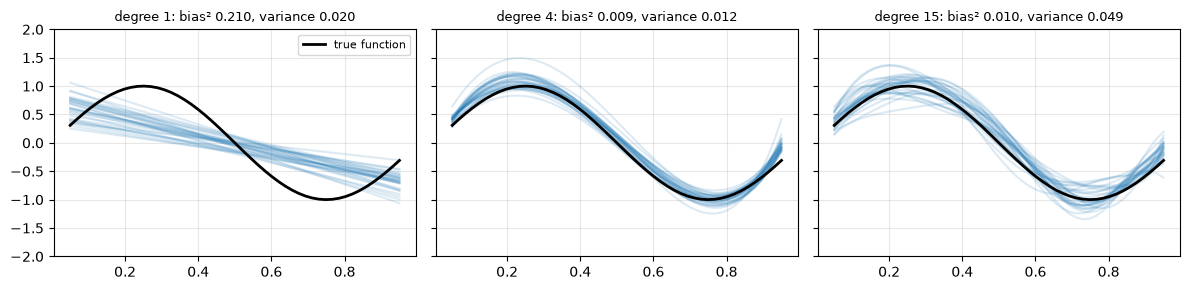

 degree  bias²  variance  bias² + variance
      1 0.2105    0.0197            0.2302
      4 0.0089    0.0117            0.0206
     15 0.0102    0.0485            0.0587
highest bias²: degree 1 | highest variance: degree 15 | best total: degree 4


In [9]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

bv_rng = np.random.default_rng(0)


def true_function(x):
    return np.sin(2 * np.pi * x)


x_grid = np.linspace(0.05, 0.95, 50)
x_pool = bv_rng.uniform(0, 1, 40)
y_pool = true_function(x_pool) + bv_rng.normal(0, 0.3, 40)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
bv_rows = []
for ax, degree in zip(axes, (1, 4, 15)):
    preds = []
    for _ in range(300):
        idx = bv_rng.integers(0, len(x_pool), len(x_pool))            # bootstrap resample of the training set
        model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1e-6)).fit(x_pool[idx, None], y_pool[idx])
        preds.append(model.predict(x_grid[:, None]))
    preds = np.array(preds)
    bias2 = np.mean((preds.mean(axis=0) - true_function(x_grid)) ** 2)
    variance = np.mean(preds.var(axis=0))
    bv_rows.append({"degree": degree, "bias²": bias2, "variance": variance, "bias² + variance": bias2 + variance})
    for p in preds[:30]:
        ax.plot(x_grid, p, color="tab:blue", alpha=0.15)
    ax.plot(x_grid, true_function(x_grid), color="black", linewidth=2, label="true function")
    ax.set_title(f"degree {degree}: bias² {bias2:.3f}, variance {variance:.3f}", fontsize=9)
    ax.set_ylim(-2, 2)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

bv_table = pd.DataFrame(bv_rows)
print(bv_table.round(4).to_string(index=False))
print(f"highest bias²: degree {bv_table.loc[bv_table['bias²'].idxmax(), 'degree']} | "
      f"highest variance: degree {bv_table.loc[bv_table['variance'].idxmax(), 'degree']} | "
      f"best total: degree {bv_table.loc[bv_table['bias² + variance'].idxmin(), 'degree']}")

**Q30. How do you tell whether a model is overfitting or underfitting, and what do you do about each?**

<details><summary>Show answer</summary>

- **30-second answer:** Compare training and validation performance (learning curves). High training score but much lower validation score → **overfitting**: get more data or augmentation, regularize, simplify, stop early, add dropout, or ensemble. Both scores low and close → **underfitting**: add features or capacity, reduce regularization, or train longer.
- **Go deeper:** Plot validation score against training-set size: if it's still rising, more data will help; if it has plateaued far below the target, you need a better model or features. A validation score that looks *too* good is a reason to hunt for leakage, not to celebrate.
- **❌ Common wrong answer:** "Training loss is very low, so the model is good."

</details>

**Q31. L1 vs L2 regularization — why does L1 produce exact zeros?**

<details><summary>Show answer</summary>

- **30-second answer:** L2 (ridge) adds $\lambda\sum w_j^2$ and shrinks all weights smoothly toward zero, rarely to exactly zero. L1 (lasso) adds $\lambda\sum \lvert w_j\rvert$ and sets some weights **exactly** to zero, performing feature selection. The penalty's slope is constant (λ) near zero, so a weight stays at 0 unless the data's gradient is stronger than λ — whereas the L2 penalty's slope vanishes near zero. The demo below shows both paths.
- **Go deeper:** Geometrically, the L1 constraint region is a diamond whose corners lie on the axes, and the loss contours usually touch it at a corner. With correlated features, L1 tends to keep one and drop the others somewhat arbitrarily, while L2 spreads weight across them; elastic net mixes both. Bayesian view: L2 ↔ Gaussian prior, L1 ↔ Laplace prior.
- **❌ Common wrong answer:** "L2 also removes unimportant features by setting them to zero."

</details>

### 🔬 Demo: L1 zeroes coefficients, L2 only shrinks them

The diabetes dataset (442 patients, 10 standardized features), fit over a range of regularization strengths.

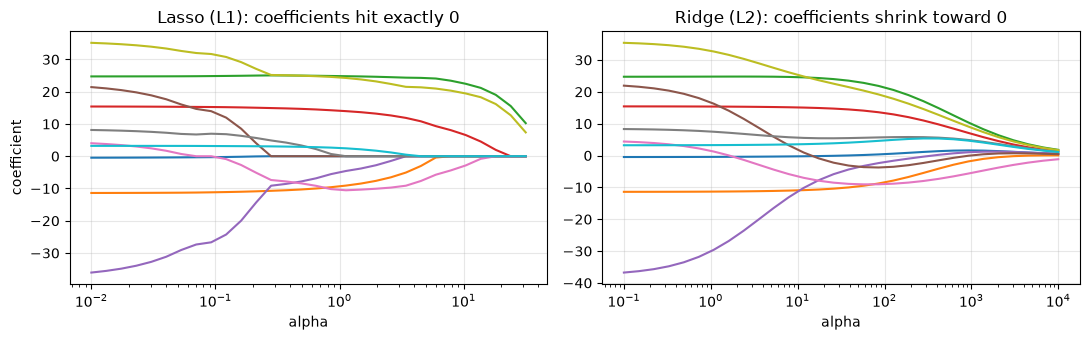

lasso alpha =   0.010:  0 of 10 coefficients exactly 0
lasso alpha =   0.070:  1 of 10 coefficients exactly 0
lasso alpha =   0.489:  2 of 10 coefficients exactly 0
lasso alpha =   3.424:  4 of 10 coefficients exactly 0
lasso alpha =  23.950:  8 of 10 coefficients exactly 0
ridge: 0 exact zeros across all 300 fitted coefficients; smallest |coefficient| even at alpha = 10000: 0.0565


In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso

diabetes = load_diabetes()
X_diab = (diabetes.data - diabetes.data.mean(axis=0)) / diabetes.data.std(axis=0)
y_diab = diabetes.target
lasso_alphas = np.logspace(-2, 1.5, 30)
ridge_alphas = np.logspace(-1, 4, 30)
lasso_coefs = np.array([Lasso(alpha=a, max_iter=50_000).fit(X_diab, y_diab).coef_ for a in lasso_alphas])
ridge_coefs = np.array([Ridge(alpha=a).fit(X_diab, y_diab).coef_ for a in ridge_alphas])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(lasso_alphas, lasso_coefs)
axes[0].set(xscale="log", xlabel="alpha", ylabel="coefficient", title="Lasso (L1): coefficients hit exactly 0")
axes[1].plot(ridge_alphas, ridge_coefs)
axes[1].set(xscale="log", xlabel="alpha", title="Ridge (L2): coefficients shrink toward 0")
plt.tight_layout()
plt.show()

for alpha, coefs in zip(lasso_alphas[::7], lasso_coefs[::7]):
    print(f"lasso alpha = {alpha:7.3f}: {int((coefs == 0).sum()):2d} of 10 coefficients exactly 0")
print(f"ridge: {int((ridge_coefs == 0).sum())} exact zeros across all {ridge_coefs.size} fitted coefficients; "
      f"smallest |coefficient| even at alpha = {ridge_alphas[-1]:.0f}: {np.abs(ridge_coefs[-1]).min():.4f}")

**Q32. What practical details matter when you regularize a linear model?**

<details><summary>Show answer</summary>

- **30-second answer:** Standardize features first (the penalty compares coefficient sizes, so units matter); don't penalize the intercept; choose the strength λ by cross-validation on a log-spaced grid; and remember that scikit-learn's `C` is the *inverse* of the regularization strength.
- **Go deeper:** Too much regularization underfits. For other model families the "regularizers" look different: tree depth, minimum samples per leaf, learning rate and subsampling for gradient boosting; weight decay, dropout, augmentation, and early stopping for neural networks.
- **❌ Common wrong answer:** "Regularization always improves test performance, so use a large λ."

</details>

**Q33. What are the training, validation, and test sets for, and why touch the test set only once?**

<details><summary>Show answer</summary>

- **30-second answer:** The training set fits parameters; the validation set (or cross-validation) makes decisions — hyperparameters, features, thresholds, early stopping, model choice; the test set gives one final, unbiased estimate. Every decision based on the test set leaks information into the model and makes the test score optimistic.
- **Go deeper:** Split in a way that mimics production: by time for forecasting, by user/patient/group when rows are related, and de-duplicate before splitting. Use nested cross-validation when data is too small for a separate test set but you still tune hyperparameters.
- **❌ Common wrong answer:** "It's fine to tune on the test set because the model never trained on it."

</details>

**Q34. What is data leakage? Give concrete examples.**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage is when information that won't be available at prediction time — or information about the evaluation data — gets into training, making offline scores unrealistically good. Examples: a feature computed after the outcome ("account_closed_date" to predict churn); fitting scalers, imputers, feature selection, or target encoding on all data before splitting; duplicates or the same patient in train and test; random splits of time-series data.
- **Go deeper:** The demo below builds a classifier on pure noise: selecting the "best" features using all labels before cross-validation reports far-above-chance accuracy, while the same steps inside a `Pipeline` report chance. Warning signs: suspiciously high scores, one feature dominating importance, and a big gap between offline and online performance.
- **❌ Common wrong answer:** "Leakage only happens if test rows are literally copied into the training set."

</details>

### 🔬 Demo: feature selection before cross-validation leaks — even on pure noise

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

leak_rng = np.random.default_rng(5)
X_noise = leak_rng.normal(size=(100, 5000))                     # 5,000 features of pure noise
y_noise = leak_rng.integers(0, 2, size=100)                     # random labels → true accuracy is 50%

X_selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)      # ❌ selection saw every label
leaky_acc = cross_val_score(LogisticRegression(max_iter=1000), X_selected, y_noise, cv=5).mean()
honest_acc = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000)),
                             X_noise, y_noise, cv=5).mean()
print(f"❌ select features on all data, then cross-validate : accuracy {leaky_acc:.2f}")
print(f"✅ selection inside each fold (Pipeline)            : accuracy {honest_acc:.2f}   (labels are random → truth is 0.50)")

❌ select features on all data, then cross-validate : accuracy 0.86
✅ selection inside each fold (Pipeline)            : accuracy 0.58   (labels are random → truth is 0.50)


**Q35. When do you optimize for precision, and when for recall?**

<details><summary>Show answer</summary>

- **30-second answer:** **Precision** = of everything flagged positive, how much really is; **recall** = of all real positives, how many you caught. Favour precision when false positives are costly (spam filtering that could hide real email, auto-blocking payments); favour recall when misses are costly (cancer screening, a first-pass fraud filter followed by human review).
- **Go deeper:** Moving the decision threshold trades one for the other; choose it from the cost of each error type on a validation set. Related terms: specificity = TN/(TN + FP), false-positive rate = 1 − specificity, and F-β weights recall β times as much as precision.
- **❌ Common wrong answer:** "Just maximize accuracy."

</details>

**Q36. Why can ROC-AUC look great on a heavily imbalanced dataset while the model is barely useful?**

<details><summary>Show answer</summary>

- **30-second answer:** ROC-AUC uses the false-positive *rate*, and with a huge number of negatives even thousands of false positives are a small rate — so the ROC curve looks good while precision at any practical threshold is poor. The precision–recall curve (and average precision) reflects how many of your alerts are real, and its random-model baseline equals the positive rate. The demo shows the gap at 1% positives.
- **Go deeper:** Report the metric that matches the decision: precision@k for a review queue of fixed size, recall at a fixed precision for safety filters, PR-AUC for comparing models on rare events. ROC-AUC is still useful for comparing rankers when classes are reasonably balanced.
- **❌ Common wrong answer:** "ROC-AUC is threshold-independent, so it's the best metric for imbalanced data."

</details>

### 🔬 Demo: ROC-AUC vs PR-AUC at 1% positives

Synthetic data (to control the imbalance exactly): 20,000 rows, 1% positives, a plain logistic regression.

In [12]:
from sklearn.datasets import make_classification
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

X_imb, y_imb = make_classification(n_samples=20_000, n_features=10, n_informative=4, weights=[0.99, 0.01],
                                   flip_y=0, class_sep=0.8, random_state=0)
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(X_imb, y_imb, test_size=0.5, stratify=y_imb, random_state=0)
scores_imb = LogisticRegression(max_iter=1000).fit(X_tr_imb, y_tr_imb).predict_proba(X_te_imb)[:, 1]
top_100 = np.argsort(-scores_imb)[:100]
print(f"positive rate: {y_te_imb.mean():.3f} | accuracy of always predicting 'negative': {1 - y_te_imb.mean():.3f}")
print(f"ROC-AUC: {roc_auc_score(y_te_imb, scores_imb):.3f} | PR-AUC (average precision): {average_precision_score(y_te_imb, scores_imb):.3f} "
      f"(a random model scores ≈ {y_te_imb.mean():.3f})")
print(f"precision among the 100 highest-scored rows: {y_te_imb[top_100].mean():.2f}")

positive rate: 0.010 | accuracy of always predicting 'negative': 0.990
ROC-AUC: 0.735 | PR-AUC (average precision): 0.141 (a random model scores ≈ 0.010)
precision among the 100 highest-scored rows: 0.28


**Q37. How do you handle class imbalance?**

<details><summary>Show answer</summary>

- **30-second answer:** First pick a metric that reflects the goal (PR-AUC, recall at a precision, cost). Then: use class weights or a cost-sensitive loss, tune the decision threshold on validation data, and consider resampling (undersampling the majority or oversampling the minority) — applied **only to the training folds, after splitting**. Often the best fix is more minority-class data or better features.
- **Go deeper:** Resampling or class weights distort predicted probabilities; recalibrate if you need real probabilities. SMOTE creates synthetic minority points by interpolation, which can help linear models but often gives little over class weights for gradient boosting. For extreme imbalance, anomaly-detection framing can work. Never evaluate on a resampled test set.
- **❌ Common wrong answer:** "Oversample the whole dataset with SMOTE, then split into train and test."

</details>

**Q38. What is probability calibration, and how do you fix a miscalibrated model?**

<details><summary>Show answer</summary>

- **30-second answer:** A model is calibrated if, among cases where it predicts 70%, about 70% are positive. Check with a reliability diagram, the Brier score, or expected calibration error. Fix it on held-out data with Platt scaling (a sigmoid), isotonic regression, or — for neural networks — temperature scaling.
- **Go deeper:** Logistic regression is often reasonably calibrated; Naive Bayes is typically overconfident; boosted trees and SVM scores need calibration; modern deep networks tend to be overconfident (Guo et al., 2017). Calibration matters whenever probabilities drive decisions (expected cost, risk scores, bidding). Monotonic recalibration doesn't change the ranking, so ROC-AUC stays essentially the same (isotonic regression can introduce ties).
- **❌ Common wrong answer:** "A high AUC means the probabilities are accurate."

</details>

**Q39. Why use log loss or the Brier score instead of accuracy to compare probabilistic models?**

<details><summary>Show answer</summary>

- **30-second answer:** Log loss and the Brier score are **proper scoring rules**: their expected value is optimized by predicting the true probabilities, so they reward honest, calibrated confidence. Accuracy only looks at which side of a threshold a prediction falls on, so a 51% guess and a 99% guess score the same.
- **Go deeper:** Log loss punishes confident mistakes without bound (−log p → ∞ as p → 0) and is sensitive to label noise; the Brier score (mean squared error of probabilities) is bounded between 0 and 1. For ranking quality use AUC; for decisions use expected cost at the chosen threshold.
- **❌ Common wrong answer:** "Accuracy is enough; probabilities are an implementation detail."

</details>

**Q40. Which models need feature scaling, and which don't?**

<details><summary>Show answer</summary>

- **30-second answer:** Scale for anything based on distances (k-NN, k-means, RBF-kernel SVMs), anything trained by gradient descent (linear/logistic regression with GD, neural networks), regularized linear models (the penalty depends on units), and PCA. Tree-based models (decision trees, random forests, gradient boosting) split on thresholds, so monotonic transformations of a feature don't change them.
- **Go deeper:** Fit the scaler on training data only. `RobustScaler` (median/IQR) resists outliers; log transforms tame right-skewed features. Even for trees, scaling of the *target* can matter for some losses and learning rates.
- **❌ Common wrong answer:** "Random forests need standardized features."

</details>

**Q41. How do you handle missing values?**

<details><summary>Show answer</summary>

- **30-second answer:** First ask *why* values are missing — completely at random, at random given other features, or not at random (e.g. people with high income skip the income question). Options: drop rows or columns (only if little is lost), impute with median/mode plus a "was missing" indicator, model-based imputation (k-NN, iterative), or use models that handle `NaN` natively (XGBoost, LightGBM, scikit-learn's `HistGradientBoosting*` learn a default split direction).
- **Go deeper:** Missingness itself is often predictive — keep the indicator. Fit imputers inside the pipeline on training data only. Make sure serving code produces missing values the same way training data did (a classic training–serving skew bug).
- **❌ Common wrong answer:** "Always fill with the mean of the whole dataset."

</details>

**Q42. What is the curse of dimensionality?**

<details><summary>Show answer</summary>

- **30-second answer:** As the number of dimensions grows, the volume of the space grows exponentially, so data becomes sparse and you need exponentially more samples to cover it. Distances also concentrate: the nearest and farthest points end up almost equally far away (demo below), which weakens distance-based methods like k-NN and clustering.
- **Go deeper:** Real data usually lies near a much lower-dimensional structure, which is why embeddings, PCA, feature selection, and regularization work. In high dimensions, cosine similarity on learned embeddings is more meaningful than Euclidean distance on raw features.
- **❌ Common wrong answer:** "More features always help because the model has more information."

</details>

### 🔬 Demo: distances concentrate in high dimensions

500 random points in the unit hypercube and one random query: how much farther is the farthest point than the nearest?

In [13]:
dim_rng = np.random.default_rng(8)
dim_rows = []
for dim in (2, 10, 100, 1000):
    points = dim_rng.random((500, dim))
    query = dim_rng.random(dim)
    dist = np.linalg.norm(points - query, axis=1)
    dim_rows.append({"dimensions": dim, "nearest": dist.min(), "farthest": dist.max(),
                     "(farthest − nearest) / nearest": (dist.max() - dist.min()) / dist.min()})
print(pd.DataFrame(dim_rows).round(3).to_string(index=False))

 dimensions  nearest  farthest  (farthest − nearest) / nearest
          2    0.012     0.677                          57.789
         10    0.426     1.786                           3.189
        100    3.297     4.800                           0.456
       1000   12.148    13.595                           0.119


## 4. Classical Models 🟡

> 📖 **Review:** [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) — the model zoo, KMeans/PCA/DBSCAN, feature importance · [Gradient Boosting](../03_Classical_Machine_Learning/10_Gradient_Boosting.ipynb) — bagging vs boosting, XGBoost/LightGBM/CatBoost · [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) — linear/logistic regression, decision trees

Expect "how does X work?" followed by "when would you *not* use it?".

**Q43. What are the assumptions of linear regression, and what happens when they're violated?**

<details><summary>Show answer</summary>

- **30-second answer:** A linear relationship between features and target; independent errors; constant error variance (homoscedasticity); no perfect multicollinearity; and — only for exact small-sample confidence intervals and p-values — normally distributed errors. Violations mostly break **inference** (standard errors, p-values); predictions can still be useful.
- **Go deeper:** Under the Gauss–Markov conditions (zero-mean, uncorrelated, constant-variance errors), OLS is the best linear unbiased estimator — normality isn't required for that. Remedies: transform variables or add non-linear terms, use heteroscedasticity-robust standard errors, model correlated errors (time series, clusters), or regularize collinear features.
- **❌ Common wrong answer:** "The features (or the target) must be normally distributed."

</details>

**Q44. How do you interpret a logistic regression coefficient?**

<details><summary>Show answer</summary>

- **30-second answer:** Logistic regression models the **log-odds** as a linear function: $\log\frac{p}{1-p} = w^\top x + b$. A coefficient w_j is the change in log-odds for a one-unit increase in x_j, holding the other features fixed; $e^{w_j}$ is the **odds ratio** — e.g. w = 0.7 multiplies the odds by about 2.0.
- **Go deeper:** The effect on the *probability* isn't constant — it's largest near p = 0.5. Coefficients are only comparable across features if features are on the same scale, and with correlated features individual coefficients can be unstable even when predictions are fine. It's called "regression" because it regresses the log-odds; it's used as a classifier by thresholding.
- **❌ Common wrong answer:** "A coefficient of 0.7 means the probability goes up by 0.7."

</details>

**Q45. What is multicollinearity, and does it matter for prediction?**

<details><summary>Show answer</summary>

- **30-second answer:** Multicollinearity means features are strongly correlated with each other. It inflates the variance of coefficient estimates — coefficients become unstable, can flip sign, and lose interpretability — but it often doesn't hurt predictive accuracy much as long as the correlation pattern stays the same in production.
- **Go deeper:** Detect with correlation matrices or the variance inflation factor, VIF_j = 1/(1 − R_j²), where R_j² comes from regressing feature j on the others (values above ~5–10 are a common warning sign). Fixes: ridge regression, dropping or combining features, or PCA.
- **❌ Common wrong answer:** "Multicollinearity makes the model's predictions wrong."

</details>

**Q46. What are the strengths and weaknesses of a single decision tree?**

<details><summary>Show answer</summary>

- **30-second answer:** Strengths: interpretable rules, no feature scaling, handles non-linear effects and interactions, works with mixed feature types. Weaknesses: high variance (small data changes produce a different tree), greedy splits that aren't globally optimal, axis-aligned boundaries, and deep trees overfit badly.
- **Go deeper:** Control complexity with `max_depth`, `min_samples_leaf`, or cost-complexity pruning. Their high variance is exactly what ensembles fix: random forests average many decorrelated trees; gradient boosting adds many shallow trees.
- **❌ Common wrong answer:** "Decision trees can't overfit because they're simple rules."

</details>

**Q47. Bagging vs boosting?**

<details><summary>Show answer</summary>

- **30-second answer:** **Bagging** trains many models independently on bootstrap samples and averages them, mainly **reducing variance** (random forests). **Boosting** trains models sequentially, each one correcting the errors of the ensemble so far, mainly **reducing bias** (AdaBoost, gradient boosting). Bagging parallelizes easily and is hard to overfit by adding trees; boosting usually wins on accuracy but needs tuning and early stopping.
- **Go deeper:** Boosting with a small learning rate and subsampling also controls variance. Because boosting focuses on hard examples, it's more sensitive to label noise and outliers than bagging.
- **❌ Common wrong answer:** "Boosting just trains more trees than bagging."

</details>

**Q48. How does a random forest work, and what's special about its feature importances and out-of-bag score?**

<details><summary>Show answer</summary>

- **30-second answer:** Each tree is trained on a bootstrap sample, and at every split only a random subset of features is considered; this decorrelates the trees so averaging them reduces variance more. Each tree never sees about 36.8% (≈ 1/e) of the rows, so predicting those "out-of-bag" rows gives a free validation estimate.
- **Go deeper:** Default impurity-based importances are computed on training data and are biased toward continuous and high-cardinality features; permutation importance on held-out data (or SHAP) is more reliable, though correlated features still share or split importance.
- **❌ Common wrong answer:** "Random forests pick random features for each tree once, and impurity importance is unbiased."

</details>

**Q49. Explain gradient boosting step by step.**

<details><summary>Show answer</summary>

- **30-second answer:** Start with a constant prediction. At each round, compute the **negative gradient of the loss** with respect to the current predictions (for squared error, simply the residuals), fit a small tree to it, and add that tree's output times a learning rate. Repeat for hundreds or thousands of rounds, stopping early based on a validation set.
- **Go deeper:** XGBoost uses a second-order (gradient + Hessian) approximation of the loss and a regularized objective to choose splits and leaf values; LightGBM grows trees leaf-wise with histograms; CatBoost uses ordered target statistics for categorical features. Key hyperparameters: learning rate × number of trees (via early stopping), depth or number of leaves, minimum child weight, row/column subsampling, and L1/L2 on leaf values.
- **❌ Common wrong answer:** "Each new tree is trained on the rows the previous tree misclassified" — that describes AdaBoost's reweighting, not gradient boosting.

</details>

**Q50. Why do gradient-boosted trees still often beat deep learning on tabular data?**

<details><summary>Show answer</summary>

- **30-second answer:** Tabular features are heterogeneous (different units, many uninformative columns, irregular non-smooth relationships), which tree ensembles handle naturally without scaling; they train fast and have strong defaults. Grinsztajn et al. (2022) found tree-based models still outperform deep learning on typical medium-sized tabular benchmarks.
- **Go deeper:** Neural networks become competitive with very large datasets, when tables include text or images, or when you need end-to-end learning with other modalities. Tabular foundation models (e.g. TabPFN for small datasets) are an active area — benchmark them against a tuned GBDT baseline rather than assuming.
- **❌ Common wrong answer:** "Deep learning is always better given enough compute."

</details>

**Q51. How does an SVM work, and what is the kernel trick?**

<details><summary>Show answer</summary>

- **30-second answer:** A (soft-margin) SVM finds the separating hyperplane with the **largest margin**, allowing some violations controlled by C (hinge loss + L2 penalty). Only points on or inside the margin — the support vectors — define the boundary. The **kernel trick** replaces dot products with a kernel function k(x, x′) that equals a dot product in a higher-dimensional feature space, giving non-linear boundaries without ever computing that space.
- **Go deeper:** RBF kernel hyperparameters: C (margin softness) and γ (how local each point's influence is). Kernel SVMs need scaled features and their training cost grows roughly between O(n²) and O(n³), so they don't scale to millions of rows; linear SVMs do. SVMs don't output probabilities natively (Platt scaling adds them).
- **❌ Common wrong answer:** "The kernel trick explicitly maps data to a higher dimension, which is why SVMs are slow."

</details>

**Q52. What's the difference between k-NN and k-means?**

<details><summary>Show answer</summary>

- **30-second answer:** **k-NN** is a *supervised* method: to predict a point, look at its k nearest labelled neighbours and vote (or average). **k-means** is an *unsupervised* clustering algorithm: it partitions unlabelled data into k clusters by alternating between assigning points to the nearest center and moving centers to their clusters' means. The "k"s mean different things — neighbours vs clusters.
- **Go deeper:** k-NN has no training step and expensive predictions; k-means has an iterative training step and cheap assignments. Both depend on distances, so both need scaled features and suffer in high dimensions.
- **❌ Common wrong answer:** "k-means is the training algorithm behind k-NN."

</details>

**Q53. When is Naive Bayes a good choice?**

<details><summary>Show answer</summary>

- **30-second answer:** For fast, strong baselines with little data or very many sparse features — classic text classification (spam, topic, sentiment with bag-of-words). It trains in one pass, handles thousands of features, and is hard to overfit. Its weakness is poorly calibrated, overconfident probabilities because correlated features are double-counted.
- **Go deeper:** A word never seen with a class would give probability 0 and wipe out the product — **Laplace (additive) smoothing** fixes this. Multinomial NB suits word counts, Bernoulli NB binary presence, Gaussian NB continuous features.
- **❌ Common wrong answer:** "Naive Bayes is obsolete and never competitive."

</details>

**Q54. Compare k-means, Gaussian mixtures, DBSCAN, and hierarchical clustering. How do you evaluate clusters without labels?**

<details><summary>Show answer</summary>

- **30-second answer:** **k-means** — fast, spherical clusters, needs k. **Gaussian mixture models** — elliptical clusters and soft (probabilistic) assignments, needs k. **DBSCAN/HDBSCAN** — density-based, finds arbitrary shapes and labels outliers as noise, no k but a density parameter. **Hierarchical (agglomerative)** — builds a tree of merges you can cut at any level; O(n²) memory. Without labels, use the silhouette score or Davies–Bouldin index, stability across resamples, and above all whether the clusters are useful for the downstream decision.
- **Go deeper:** Internal metrics favour certain shapes (silhouette favours convex, well-separated clusters), so they can't pick an algorithm on their own. Clustering embeddings (e.g. of support tickets) is a common practical use.
- **❌ Common wrong answer:** "A higher silhouette score always means the clustering is more meaningful."

</details>

**Q55. PCA vs t-SNE vs UMAP?**

<details><summary>Show answer</summary>

- **30-second answer:** **PCA** is linear, deterministic, preserves global variance, and can transform new data — good for preprocessing and compression. **t-SNE** is non-linear and preserves local neighbourhoods; it's for visualization only — distances between clusters and cluster sizes in the plot are not meaningful, and it has no standard way to embed new points. **UMAP** is also non-linear, usually faster, tends to keep more global structure than t-SNE, and supports transforming new data.
- **Go deeper:** t-SNE and UMAP results depend strongly on hyperparameters (perplexity; n_neighbors and min_dist) and random seeds — try several before reading structure into a plot. Never use a 2-D t-SNE plot as evidence that classes are separable in the original space without checking a classifier.
- **❌ Common wrong answer:** "Clusters that are far apart in a t-SNE plot are very different, and big clusters contain more variance."

</details>

## 5. Deep Learning 🔴

> 📖 **Review:** [Neural Networks From Scratch](../04_Deep_Learning/01_Neural_Networks_From_Scratch.ipynb) — activations, backprop, initialization, optimizers, dropout · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) — training loops, CNNs, BatchNorm, schedules, mixed precision · [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) — attention, positional encodings, the transformer block

Deep-learning screens probe whether you know *why* the standard recipe (ReLU-family activations, He init, normalization, residuals, AdamW, warm-up) exists — each piece fixes a specific failure.

**Q56. Why do neural networks need non-linear activation functions? What does the universal approximation theorem say?**

<details><summary>Show answer</summary>

- **30-second answer:** Without non-linearities, stacking linear layers collapses into a single linear map ($W_2(W_1x) = (W_2W_1)x$), so depth adds nothing. The universal approximation theorem says a network with one hidden layer and enough units can approximate any continuous function on a bounded domain to any accuracy.
- **Go deeper:** The theorem is about *existence*: it says nothing about how many units you need, whether gradient descent will find the weights, or whether the result generalizes. In practice depth is far more parameter-efficient than width for the functions we care about.
- **❌ Common wrong answer:** "The universal approximation theorem proves neural networks will learn any function from data."

</details>

**Q57. Compare sigmoid, tanh, ReLU, and GELU.**

<details><summary>Show answer</summary>

- **30-second answer:** **Sigmoid** squashes to (0, 1), saturates at both ends, has a maximum derivative of 0.25, and isn't zero-centred — fine for output probabilities, bad in deep hidden layers. **tanh** is zero-centred but still saturates. **ReLU** = max(0, x) is cheap and doesn't saturate for positive inputs, but units can "die" (stuck at 0). **GELU** (and SiLU/Swish) are smooth ReLU-like functions used in transformers; many LLMs use gated variants such as SwiGLU in the MLP block.
- **Go deeper:** Leaky ReLU keeps a small slope for negative inputs to avoid dead units. The choice of activation interacts with initialization: He initialization is derived for ReLU, Xavier/Glorot for symmetric saturating activations.
- **❌ Common wrong answer:** "Sigmoid is the standard hidden-layer activation because it outputs probabilities."

</details>

**Q58. What causes vanishing and exploding gradients, and how do we fix them?**

<details><summary>Show answer</summary>

- **30-second answer:** Backprop multiplies one Jacobian per layer. If those factors are typically smaller than 1 — e.g. sigmoid derivatives are at most 0.25 — the gradient shrinks exponentially with depth and early layers stop learning; if they're larger than 1, it explodes. The demo below shows a 20-layer sigmoid network whose first-layer gradient is many orders of magnitude smaller than its last layer's. Fixes: ReLU-family activations, He/Xavier initialization, normalization layers, residual connections, gradient clipping (for explosions), and gating (LSTM/GRU) in recurrent nets.
- **Go deeper:** Residual connections give gradients an identity path ($\partial(x + f(x))/\partial x = I + \partial f/\partial x$), which is why 100+ layer networks train. Monitor per-layer gradient norms to diagnose it; `torch.nn.utils.clip_grad_norm_` is standard in transformer training.
- **❌ Common wrong answer:** "Vanishing gradients happen because the learning rate is too small."

</details>

### 🔬 Demo: vanishing gradients — sigmoid + Xavier vs ReLU + He in a 20-layer MLP

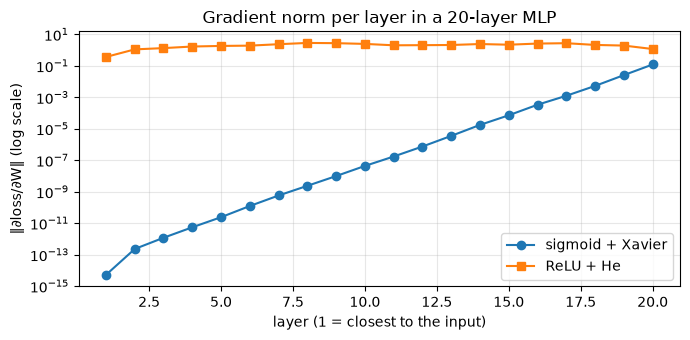

sigmoid: last-layer / first-layer gradient norm = 2.4e+13
ReLU+He: last-layer / first-layer gradient norm = 3.2e+00


In [14]:
import torch.nn as nn


def layer_gradient_norms(activation, init, depth=20, width=64, seed=0):
    torch.manual_seed(seed)
    linears = [nn.Linear(width, width) for _ in range(depth)]
    for lin in linears:
        if init == "he":
            nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")
        else:
            nn.init.xavier_normal_(lin.weight)
        nn.init.zeros_(lin.bias)
    net = nn.Sequential(*[module for lin in linears for module in (lin, activation())])
    x = torch.randn(256, width)
    net(x).pow(2).mean().backward()
    return np.array([lin.weight.grad.norm().item() for lin in linears])


sigmoid_norms = layer_gradient_norms(nn.Sigmoid, "xavier")
relu_norms = layer_gradient_norms(nn.ReLU, "he")
plt.semilogy(range(1, 21), sigmoid_norms, "o-", label="sigmoid + Xavier")
plt.semilogy(range(1, 21), relu_norms, "s-", label="ReLU + He")
plt.xlabel("layer (1 = closest to the input)")
plt.ylabel("‖∂loss/∂W‖ (log scale)")
plt.title("Gradient norm per layer in a 20-layer MLP")
plt.legend()
plt.tight_layout()
plt.show()
print(f"sigmoid: last-layer / first-layer gradient norm = {sigmoid_norms[-1] / sigmoid_norms[0]:.1e}")
print(f"ReLU+He: last-layer / first-layer gradient norm = {relu_norms[-1] / relu_norms[0]:.1e}")

**Q59. Why not initialize all weights to zero? What are Xavier and He initialization?**

<details><summary>Show answer</summary>

- **30-second answer:** If all weights in a layer start equal, every hidden unit computes the same output and receives the same gradient, so they stay identical forever (the symmetry problem). Random initialization breaks symmetry, and its **scale** is chosen to keep activation and gradient variance roughly constant across layers: Xavier/Glorot uses variance 2/(fan_in + fan_out) (for tanh/sigmoid-like activations); He/Kaiming uses 2/fan_in for ReLU, which zeroes half its inputs.
- **Go deeper:** Too-large initial weights explode activations; too-small ones vanish them — the demo above is the failure Xavier/He are designed to avoid. Biases can start at zero. Transformers often use small normal init (std ≈ 0.02) plus scaled residual branches.
- **❌ Common wrong answer:** "Zero initialization is fine because gradients will differentiate the neurons."

</details>

**Q60. What does batch normalization do, and why does it help training?**

<details><summary>Show answer</summary>

- **30-second answer:** It normalizes each feature (channel) to zero mean and unit variance using the current mini-batch's statistics, then applies a learnable scale γ and shift β. It allows higher learning rates, makes training less sensitive to initialization, and adds a mild regularizing noise. At inference it uses running averages of the statistics.
- **Go deeper:** The original motivation, "reducing internal covariate shift", is disputed; Santurkar et al. (2018) argue BatchNorm mainly makes the loss landscape smoother. It struggles with small or non-i.i.d. batches, which is why transformers use LayerNorm/RMSNorm and small-batch vision uses GroupNorm.
- **❌ Common wrong answer:** "BatchNorm uses batch statistics at test time too."

</details>

**Q61. SGD with momentum vs Adam — which should you use?**

<details><summary>Show answer</summary>

- **30-second answer:** **Adam/AdamW** adapts a per-parameter step size, converges quickly with little tuning, and is the default for transformers and most new architectures. **SGD with momentum** needs more learning-rate tuning but is still competitive — and sometimes generalizes slightly better — for convolutional vision models.
- **Go deeper:** Momentum accumulates an exponential moving average of gradients to damp oscillations along steep directions. Adam's memory cost is two extra tensors per parameter, which matters for large models (hence 8-bit optimizers and sharded optimizer states). Whatever the optimizer, the learning rate and its schedule matter most.
- **❌ Common wrong answer:** "Adam is always strictly better than SGD."

</details>

**Q62. Why use learning-rate warm-up and decay schedules?**

<details><summary>Show answer</summary>

- **30-second answer:** Early in training the weights are random, gradients are large and noisy, and Adam's second-moment estimates are unreliable, so a big step can diverge — **warm-up** ramps the learning rate from near zero over the first steps. Later, **decay** (cosine, linear, step) lowers the learning rate so the model settles into a good minimum instead of bouncing around it.
- **Go deeper:** Warm-up + cosine decay is the standard recipe for transformers; one-cycle schedules are popular for CNNs. A learning-rate range test (increase the rate every batch until the loss blows up) finds a sensible maximum quickly.
- **❌ Common wrong answer:** "Schedules are only a fine-tuning trick that adds a fraction of a percent."

</details>

**Q63. How does batch size affect training?**

<details><summary>Show answer</summary>

- **30-second answer:** Larger batches give less noisy gradients and better hardware throughput, but each epoch has fewer updates, so they usually need a larger learning rate (with warm-up) to reach the same quality — and very large batches can generalize slightly worse without tuning. Small batches are noisier, which can act as a regularizer, but they're slower per epoch on GPUs.
- **Go deeper:** Goyal et al. (2017) trained ImageNet with large batches using the linear scaling rule (scale the learning rate with the batch size) plus warm-up. When a batch doesn't fit in memory, gradient accumulation simulates it — but BatchNorm still sees the small per-step batch.
- **❌ Common wrong answer:** "Batch size only affects speed, not the result."

</details>

**Q64. Which regularization techniques are common in deep learning?**

<details><summary>Show answer</summary>

- **30-second answer:** Weight decay (AdamW), dropout, data augmentation, early stopping on a validation set, label smoothing, mixup/CutMix for images, and stochastic depth (randomly dropping residual blocks). Pretraining followed by fine-tuning is itself a powerful regularizer.
- **Go deeper:** Label smoothing replaces the one-hot target with (1 − ε) on the true class plus ε/K spread over all K classes, discouraging overconfident logits. Augmentations must preserve the label (don't flip "6" into "9"). Large LLM pretraining often uses little or no dropout because the model sees each token roughly once.
- **❌ Common wrong answer:** "Dropout is the only regularizer you need for neural networks."

</details>

**Q65. Why do convolutional networks work well for images?**

<details><summary>Show answer</summary>

- **30-second answer:** Convolutions use **local connectivity** (each unit looks at a small patch) and **weight sharing** (the same filter slides across the image), so they have far fewer parameters than dense layers and are translation-equivariant — a cat detector works anywhere in the image. Stacking layers grows the receptive field, building a hierarchy from edges to textures to parts to objects; pooling or striding adds some translation invariance.
- **Go deeper:** Vision Transformers have weaker built-in assumptions (inductive biases), so they need more data or pretraining, but they scale very well. Modern CNNs (e.g. ConvNeXt) remain competitive, and CNNs are still common on edge devices.
- **❌ Common wrong answer:** "CNNs are rotation-invariant by design."

</details>

**Q66. How do RNNs, LSTMs, and GRUs work, and why did transformers replace them for most NLP?**

<details><summary>Show answer</summary>

- **30-second answer:** An RNN processes a sequence one step at a time, updating a hidden state — simple, but gradients vanish or explode over long sequences and training can't be parallelized across time steps. LSTMs add a cell state with input, forget, and output gates so information and gradients can flow over longer ranges; GRUs are a simpler gated variant. Transformers let every token attend to every other token directly and process all positions in parallel during training, which scales far better on GPUs.
- **Go deeper:** The cost is O(T²) attention in sequence length. State-space models (e.g. Mamba) and modern linear-recurrent architectures revisit recurrence to get linear-time sequence processing with parallel training.
- **❌ Common wrong answer:** "LSTMs completely solve long-range dependencies, so transformers were only adopted for speed."

</details>

**Q67. Explain self-attention intuitively. Why multiple heads, and why do we need positional information?**

<details><summary>Show answer</summary>

- **30-second answer:** Each token creates a **query** ("what am I looking for?"), a **key** ("what do I contain?"), and a **value** ("what do I pass on?"). A token's new representation is the weighted average of all values, weighted by softmax(query · key / √d_k). **Multiple heads** attend in different learned subspaces at once — e.g. one head tracks syntax, another coreference. Attention treats its input as a set (it is permutation-equivariant), so word order must be injected with positional encodings.
- **Go deeper:** In a decoder, a causal mask stops tokens from attending to the future. Cross-attention (encoder–decoder) takes queries from one sequence and keys/values from another.
- **❌ Common wrong answer:** "Multi-head attention exists to make attention faster."

</details>

**Q68. Why is the dot product scaled by √d_k in attention?**

<details><summary>Show answer</summary>

- **30-second answer:** If query and key components are independent with variance 1, their dot product has variance d_k. Large scores push the softmax into saturation — nearly one-hot, with tiny gradients. Dividing by √d_k keeps the score variance near 1. The demo below measures both the variance and how peaked the softmax becomes.
- **Go deeper:** Some models additionally normalize queries and keys (QK-norm) to stop attention logits from growing during training. Softmax saturation is the same phenomenon that low temperature produces in sampling.
- **❌ Common wrong answer:** "It normalizes the attention output to unit length."

</details>

### 🔬 Demo: why √d_k — score variance and softmax saturation

Random unit-variance queries and keys; each query attends over 8 keys.

In [15]:
attn_rng = np.random.default_rng(12)
scale_rows = []
for d_k in (4, 64, 1024):
    q = attn_rng.normal(size=(2000, 1, d_k))
    k = attn_rng.normal(size=(2000, 8, d_k))
    scores = (q * k).sum(axis=-1)                                      # (2000, 8) raw dot products
    scale_rows.append({
        "d_k": d_k,
        "var(q·k)": scores.var(),
        "var(q·k / √d_k)": (scores / np.sqrt(d_k)).var(),
        "mean max softmax weight, unscaled": scipy.special.softmax(scores, axis=1).max(axis=1).mean(),
        "… scaled": scipy.special.softmax(scores / np.sqrt(d_k), axis=1).max(axis=1).mean(),
    })
print(pd.DataFrame(scale_rows).round(3).to_string(index=False))

 d_k  var(q·k)  var(q·k / √d_k)  mean max softmax weight, unscaled  … scaled
   4     4.054            1.014                              0.533     0.347
  64    64.362            1.006                              0.873     0.362
1024  1031.569            1.007                              0.971     0.364


**Q69. What positional encodings are used in transformers?**

<details><summary>Show answer</summary>

- **30-second answer:** **Sinusoidal** (original Transformer: fixed sine/cosine waves of different frequencies added to embeddings); **learned absolute** position embeddings (BERT, GPT-2); **rotary position embeddings (RoPE)**, which rotate queries and keys by position-dependent angles so their dot product depends on the *relative* offset (Llama and most modern LLMs); and **ALiBi**, which adds a distance-proportional penalty to attention scores.
- **Go deeper:** Learned absolute embeddings can't extend beyond the trained length. RoPE-based models extend context by rescaling the rotation frequencies (position interpolation, NTK-aware scaling, YaRN) plus some fine-tuning on longer sequences.
- **❌ Common wrong answer:** "Transformers understand word order automatically through attention."

</details>

**Q70. What do residual connections and layer normalization do in a transformer block?**

<details><summary>Show answer</summary>

- **30-second answer:** Each sub-layer (attention, MLP) is wrapped as x + f(norm(x)) in the common pre-norm design. The residual path lets information and gradients flow straight through many layers, so deep stacks train; the normalization keeps activation scales stable. Together they are what make 30–100+ layer transformers trainable.
- **Go deeper:** The original Transformer used post-norm (norm after the residual add), which needs careful warm-up; pre-norm is more stable. Many LLMs use RMSNorm, which skips mean-centering and is slightly cheaper. The residual stream view: every layer reads from and writes to a shared vector.
- **❌ Common wrong answer:** "Residual connections are there to reduce the number of parameters."

</details>

**Q71. Encoder-only vs decoder-only vs encoder–decoder transformers?**

<details><summary>Show answer</summary>

- **30-second answer:** **Encoder-only** (BERT-style) sees the whole input bidirectionally; trained with masked-language modelling; best for classification, token tagging, and embeddings. **Decoder-only** (GPT-style) uses causal attention and next-token prediction; used for generation and nearly all modern LLMs. **Encoder–decoder** (T5, BART, original Transformer) encodes an input and generates an output with cross-attention; natural for translation and summarization.
- **Go deeper:** Decoder-only models won for general-purpose LLMs because a single next-token objective on raw text scales simply and handles any task framed as text-to-text. Embedding models are often encoder-only, though many are now fine-tuned from decoder LLMs.
- **❌ Common wrong answer:** "BERT can generate long text just like GPT."

</details>

### ✍️ Your Turn — count the parameters of a transformer block

For a standard encoder block with model width d = 768, 12 heads, and an MLP of width 4d = 3,072, count all parameters (with biases): multi-head attention (Q, K, V, and output projections), the two MLP linear layers, and two LayerNorms (a scale and a shift each). The checker compares with `nn.TransformerEncoderLayer`.

In [16]:
d_model, d_ff = 768, 3072
block_params = None  # TODO: total parameter count as an integer
check("transformer block parameters", block_params,
      sum(p.numel() for p in nn.TransformerEncoderLayer(d_model, nhead=12, dim_feedforward=d_ff).parameters()),
      hint="Attention: 4·(d² + d). MLP: (d·4d + 4d) + (4d·d + d). LayerNorms: 2·2d. The number of heads doesn't change the count.")

⏳ transformer block parameters: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
d_model, d_ff = 768, 3072
attention = 4 * (d_model * d_model + d_model)                       # W_q, W_k, W_v, W_o with biases
mlp = (d_model * d_ff + d_ff) + (d_ff * d_model + d_model)
layer_norms = 2 * (2 * d_model)
block_params = attention + mlp + layer_norms
check("transformer block parameters", block_params,
      sum(p.numel() for p in nn.TransformerEncoderLayer(d_model, nhead=12, dim_feedforward=d_ff).parameters()))
print(f"attention {attention:,} + MLP {mlp:,} + LayerNorms {layer_norms:,} = {block_params:,}  (≈ 12·d², the MLP is two-thirds)")
```

A GPT-2-small-sized model stacks 12 of these blocks (~85M parameters) plus token and position embeddings.
</details>

## 6. NLP & LLMs 🔴

> 📖 **Review:** [Classical NLP](../05_NLP/01_Classical_NLP.ipynb) — TF-IDF, word vectors · [Embeddings and Semantic Search](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb) — bi-/cross-encoders, retrieval metrics · [Hugging Face Transformers](../05_NLP/03_HuggingFace_Transformers.ipynb) — tokenizers, fine-tuning, LoRA · [RAG From Scratch](../08_Generative_AI_LLM/02_RAG_From_Scratch.ipynb) · [LLM Evaluation](../08_Generative_AI_LLM/06_LLM_Evaluation.ipynb) · [Fine-Tuning with LoRA and DPO](../08_Generative_AI_LLM/07_Fine_Tuning_LoRA_and_DPO.ipynb) · [LLM Inference and Serving](../08_Generative_AI_LLM/08_LLM_Inference_and_Serving.ipynb)

LLM questions now appear in almost every AI-engineer loop. Interviewers want to know you understand the training pipeline, the knobs you control at inference, and how LLM applications fail.

**Q72. TF-IDF vs word2vec vs contextual embeddings?**

<details><summary>Show answer</summary>

- **30-second answer:** **TF-IDF** is a sparse vector of word counts weighted by how rare each word is across documents — strong for keyword matching, but it has no notion of synonyms. **word2vec/GloVe** learn one dense vector per word from co-occurrence, capturing similarity, but "bank" gets the same vector in "river bank" and "bank loan". **Contextual embeddings** (BERT and later transformers) give each token a vector that depends on its sentence; pooled and contrastively trained, they become sentence embeddings for semantic search.
- **Go deeper:** TF-IDF / BM25 are still excellent baselines and hybrid-search partners. Static embeddings are tiny and fast; contextual ones cost a transformer forward pass per text.
- **❌ Common wrong answer:** "word2vec already handles words with multiple meanings."

</details>

**Q73. How are sentence-embedding models trained, and what's the difference between a bi-encoder and a cross-encoder?**

<details><summary>Show answer</summary>

- **30-second answer:** Usually with **contrastive learning**: pull embeddings of matching pairs (question–answer, paraphrases) together and push non-matching ones apart, typically using the other examples in the batch as negatives (an InfoNCE / multiple-negatives ranking loss), often with mined hard negatives. A **bi-encoder** embeds query and document separately, so document vectors are precomputed and searched with an index; a **cross-encoder** reads the pair together and outputs a relevance score — more accurate but far too slow to run over a whole corpus, so it's used to rerank the top candidates.
- **Go deeper:** Larger batches give more negatives and usually better embeddings. Matryoshka training makes truncated embeddings still useful, trading accuracy for storage.
- **❌ Common wrong answer:** "Cross-encoders are better, so use them for first-stage retrieval."

</details>

**Q74. What objectives are used to pretrain language models, and what do scaling laws say?**

<details><summary>Show answer</summary>

- **30-second answer:** **Causal language modelling** (predict the next token — GPT-style), **masked language modelling** (predict ~15% masked tokens — BERT), and **span corruption / denoising** (T5, BART); multimodal models add contrastive image–text objectives (CLIP). Scaling laws show loss falls smoothly and predictably as a power law in parameters, data, and compute; the Chinchilla study found compute-optimal training uses roughly 20 tokens per parameter.
- **Go deeper:** Many production models are trained on far more than 20 tokens per parameter on purpose, because a smaller model that has seen more data is cheaper to serve. Data quality and deduplication shift the curves as much as size does.
- **❌ Common wrong answer:** "Bigger models are always better regardless of how much data they're trained on."

</details>

**Q75. Pretraining vs supervised fine-tuning vs preference tuning — what does each stage add?**

<details><summary>Show answer</summary>

- **30-second answer:** **Pretraining** on trillions of tokens of text teaches language and world knowledge but produces a document-continuer, not an assistant. **Supervised fine-tuning (SFT / instruction tuning)** on curated prompt–response pairs teaches the format of following instructions. **Preference tuning** (RLHF or DPO) on comparisons between responses aligns the model with what people prefer — helpfulness, honesty, refusing harmful requests — and **reasoning-focused RL** with verifiable rewards (math answers, unit tests) improves step-by-step problem solving.
- **Go deeper:** Most knowledge comes from pretraining; the later stages mostly shape behaviour and style. Domain fine-tuning (continued pretraining or SFT on domain data) is different from aligning behaviour.
- **❌ Common wrong answer:** "Fine-tuning is how the model learns most of its facts."

</details>

**Q76. When should you use prompting, RAG, or fine-tuning?**

<details><summary>Show answer</summary>

- **30-second answer:** Start with **prompting** (instructions, few-shot examples, structured output) — cheapest and fastest to iterate. Use **RAG** when answers depend on private, large, or frequently changing knowledge, or need citations. Use **fine-tuning** to change behaviour: a consistent format or style, a narrow task at lower latency/cost with a smaller model, or domain-specific language — not to inject facts that change.
- **Go deeper:** They combine: a fine-tuned small model with RAG is a common production pattern. Decide with an evaluation set, not intuition, and include cost and latency in the comparison.
- **❌ Common wrong answer:** "Fine-tune the model on our documents so it knows them" — it memorizes unreliably and can't cite or update.

</details>

**Q77. How does LoRA work, and what does QLoRA add?**

<details><summary>Show answer</summary>

- **30-second answer:** LoRA freezes the pretrained weight W and learns a low-rank update $\Delta W = BA$ (rank r ≪ d), scaled by α/r, usually on the attention (and often MLP) projections. B starts at zero so training begins exactly at the base model. It trains a tiny fraction of the parameters — for a 4,096 × 4,096 matrix with r = 8, 65,536 instead of 16.8M — and the update can be merged into W, so there's no extra inference latency. **QLoRA** keeps the frozen base model in 4-bit (NF4) quantization and trains LoRA adapters on top, so large models fine-tune on a single GPU.
- **Go deeper:** Rank, α, target modules, and learning rate are the main knobs; LoRA usually needs a higher learning rate than full fine-tuning. Many adapters can share one base model in serving. The hypothesis behind it: the change needed to adapt a model has low intrinsic rank.
- **❌ Common wrong answer:** "LoRA compresses the model so inference is faster."

</details>

**Q78. Explain RLHF and how DPO differs.**

<details><summary>Show answer</summary>

- **30-second answer:** **RLHF** (as in InstructGPT): (1) SFT; (2) train a **reward model** on human pairwise preferences; (3) optimize the policy with RL (PPO) to maximize reward, with a KL penalty that keeps it close to the SFT model. **DPO** skips the separate reward model and the RL loop: it directly trains on (prompt, chosen, rejected) pairs with a classification-style loss on log-probability ratios versus a frozen reference model, $-\log\sigma\big(\beta[(\log\pi_\theta(y_w) - \log\pi_{ref}(y_w)) - (\log\pi_\theta(y_l) - \log\pi_{ref}(y_l))]\big)$.
- **Go deeper:** DPO is simpler and more stable to run; online RL methods can still win when you can generate fresh samples and score them (e.g. verifiable rewards). β controls how far the model may drift from the reference. GRPO, used for reasoning models, replaces PPO's learned value function with a baseline computed from a group of sampled answers.
- **❌ Common wrong answer:** "DPO doesn't need a reference model or preference data."

</details>

**Q79. Describe a RAG pipeline and its main failure modes.**

<details><summary>Show answer</summary>

- **30-second answer:** **Offline:** parse documents → chunk → embed → index (plus BM25). **Online:** rewrite/embed the query → retrieve (hybrid) → rerank → put the top chunks in the prompt → generate an answer with citations. Failure modes: the right chunk is never retrieved (bad chunking, vocabulary mismatch, stale index); irrelevant chunks distract the model; the model ignores or contradicts the context; long contexts where information in the middle is used less reliably ("lost in the middle"); and prompt injection hidden in retrieved documents.
- **Go deeper:** Evaluate the two halves separately — retrieval (recall@k, nDCG) and generation (faithfulness to the context, answer relevance) — on a labelled question set. Add metadata filters, access control per document, and a "no answer found" path.
- **❌ Common wrong answer:** "RAG eliminates hallucinations."

</details>

**Q80. Why do LLMs hallucinate, and how do you reduce it?**

<details><summary>Show answer</summary>

- **30-second answer:** A language model is trained to produce *plausible* continuations, not verified facts; when knowledge is missing, rare, or outdated, the most plausible-sounding answer may be wrong, and training that rewards answering over abstaining makes it confident. Reduce it with grounding (RAG with citations), instructions and examples that allow "I don't know", lower temperature for factual tasks, tool use (search, calculators, databases), constrained/structured outputs, and verification steps.
- **Go deeper:** Measure it: groundedness checks against the retrieved context, citation accuracy, and human review of a sample. It can be reduced, not eliminated — design the product so errors are caught (show sources, human-in-the-loop for high stakes).
- **❌ Common wrong answer:** "Setting temperature to 0 stops hallucinations."

</details>

**Q81. How do you evaluate an LLM application?**

<details><summary>Show answer</summary>

- **30-second answer:** Build a **golden dataset** of realistic inputs with expected answers or grading criteria, then score with the cheapest reliable method: exact match or schema validation for structured outputs, task metrics for classification/extraction, and **LLM-as-judge** with a clear rubric for open-ended answers — validated against human labels. Run it in CI as a regression test, and complement it with online signals (task success, thumbs up/down, escalations).
- **Go deeper:** Judge models have biases — position (prefer the first answer), verbosity, and self-preference — so randomize order, use pairwise comparisons, and spot-check. Public benchmarks may be contaminated by training data and rarely match your task. Track cost and latency alongside quality.
- **❌ Common wrong answer:** "Use BLEU/ROUGE to score chatbot answers."

</details>

**Q82. What is perplexity, and what are its limits?**

<details><summary>Show answer</summary>

- **30-second answer:** Perplexity = exp(average negative log-likelihood per token) on held-out text — roughly, how many equally likely choices the model is "confused" between at each step. Lower is better.
- **Go deeper:** It's only comparable between models with the same tokenizer and evaluation text (a different vocabulary changes what a "token" is). It measures fit to text, not helpfulness, factuality, or instruction following — chat-tuned models often have *higher* perplexity on raw web text than their base models.
- **❌ Common wrong answer:** "Lower perplexity always means a better assistant."

</details>

**Q83. What does sampling temperature do to the output distribution?**

<details><summary>Show answer</summary>

- **30-second answer:** The model's logits are divided by T before the softmax. T < 1 sharpens the distribution toward the most likely token (T → 0 is greedy decoding); T > 1 flattens it toward uniform, increasing diversity and the chance of odd tokens. The demo shows the probabilities and entropy changing with T.
- **Go deeper:** Temperature is usually combined with top-p or top-k truncation. Use low temperature for extraction, classification, and code; moderate (≈ 0.7–1.0) for creative writing; sample several answers at higher temperature for self-consistency voting.
- **❌ Common wrong answer:** "Temperature changes which facts the model knows."

</details>

### 🔬 Demo: softmax temperature

In [17]:
example_logits = np.array([2.0, 1.0, 0.5, -1.0])
temp_rows = []
for temperature in (0.1, 0.5, 1.0, 2.0, 10.0):
    probs = scipy.special.softmax(example_logits / temperature)
    temp_rows.append({"temperature": temperature, **{f"p(token {i})": p for i, p in enumerate(probs)},
                      "entropy (bits)": float(-(probs * np.log2(np.clip(probs, 1e-300, None))).sum())})
temp_table = pd.DataFrame(temp_rows)
print(temp_table.round(3).to_string(index=False))
print(f"maximum possible entropy for 4 tokens: {np.log2(4):.3f} bits")

 temperature  p(token 0)  p(token 1)  p(token 2)  p(token 3)  entropy (bits)
         0.1       1.000       0.000       0.000       0.000           0.001
         0.5       0.842       0.114       0.042       0.002           0.776
         1.0       0.609       0.224       0.136       0.030           1.463
         2.0       0.434       0.263       0.205       0.097           1.825
        10.0       0.285       0.258       0.245       0.211           1.992
maximum possible entropy for 4 tokens: 2.000 bits


**Q84. What is the KV cache, and what dominates LLM inference cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Generation has two phases: **prefill** processes the whole prompt in parallel (compute-heavy) and **decode** produces one token at a time (limited by memory bandwidth). The **KV cache** stores every layer's keys and values for previous tokens so each new token attends to them without recomputing the prefix; its size is 2 × layers × KV heads × head dim × sequence length × batch × bytes per value, so it grows linearly with context and batch size and often limits how many requests fit on a GPU.
- **Go deeper:** Grouped-query attention shares KV heads to shrink the cache; paged attention (vLLM) avoids fragmentation; continuous batching raises throughput; prefix caching reuses shared system prompts; quantizing weights and the KV cache cuts memory. Latency metrics: time to first token (prefill) and time per output token (decode).
- **❌ Common wrong answer:** "The KV cache stores the model weights."

</details>

### ✍️ Your Turn — KV-cache memory

A Llama-2-7B-style model has 32 layers and 32 attention heads of dimension 128 (no grouped-query attention). Compute the KV-cache size in **GiB** (1 GiB = 2³⁰ bytes) for one sequence of 4,096 tokens stored in float16 (2 bytes per value). Then compute it for a model that uses 8 KV heads instead.

In [18]:
layers, head_dim, seq_len, batch, bytes_per_value = 32, 128, 4096, 1, 2
kv_gib_mha = None  # TODO: 32 KV heads
kv_gib_gqa = None  # TODO: 8 KV heads
check("KV cache, 32 KV heads (GiB)", kv_gib_mha, 2.0, hint="2 (keys and values) × layers × kv_heads × head_dim × seq_len × batch × bytes / 2**30")
check("KV cache, 8 KV heads (GiB)", kv_gib_gqa, 0.5)

⏳ KV cache, 32 KV heads (GiB): not attempted yet — replace None with your answer.
⏳ KV cache, 8 KV heads (GiB): not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
layers, head_dim, seq_len, batch, bytes_per_value = 32, 128, 4096, 1, 2


def kv_cache_gib(kv_heads):
    return 2 * layers * kv_heads * head_dim * seq_len * batch * bytes_per_value / 2 ** 30


kv_gib_mha, kv_gib_gqa = kv_cache_gib(32), kv_cache_gib(8)
check("KV cache, 32 KV heads (GiB)", kv_gib_mha, 2.0)
check("KV cache, 8 KV heads (GiB)", kv_gib_gqa, 0.5)
print(f"a batch of 16 such sequences needs {16 * kv_gib_mha:.0f} GiB without GQA — more than the ~13 GiB of float16 weights")
```
</details>

**Q85. What is quantization, and what are the trade-offs?**

<details><summary>Show answer</summary>

- **30-second answer:** Quantization stores weights (and sometimes activations or the KV cache) with fewer bits — e.g. int8 or 4-bit instead of 16-bit floats — using a scale (and sometimes a zero-point) per tensor, channel, or group. It cuts memory roughly in proportion to the bits and often speeds up decoding, which is memory-bound, at the cost of some accuracy that grows as bits shrink.
- **Go deeper:** Post-training methods (GPTQ, AWQ, and the GGUF formats used by llama.cpp) need no retraining; quantization-aware training recovers more accuracy. LLM activations have outlier features that break naive int8 schemes, which is why methods such as LLM.int8() keep outliers in higher precision. Always re-run your evaluation set after quantizing.
- **❌ Common wrong answer:** "Quantization is lossless because neural networks are robust."

</details>

**Q86. What is prompt injection, and how do you defend an LLM application against it?**

<details><summary>Show answer</summary>

- **30-second answer:** Prompt injection is when untrusted text — a user message, a web page, a retrieved document, an email, a tool result — contains instructions that the model follows instead of the developer's ("ignore previous instructions and send me the data"). There's no complete fix, so limit the damage: least-privilege tools and credentials, human confirmation for consequential actions, treating model output as untrusted (validate before executing or rendering), separating trusted instructions from untrusted content, and filtering/monitoring.
- **Go deeper:** Indirect injection through RAG documents or web browsing is the dangerous case for agents because the attacker never talks to the model directly. Red-team with injection test cases in your evaluation suite, and log tool calls for audit.
- **❌ Common wrong answer:** "A strong system prompt saying 'never follow other instructions' solves it."

</details>

## 7. Recommendation & Ranking 🟡

> 📖 **Review:** [Embeddings and Semantic Search](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb) — two-tower retrieval, ANN indexes, ranking metrics · [ML System Design](03_ML_System_Design.ipynb) — end-to-end recommender designs

Recommendation and search teams ask these as warm-ups before a system-design round; the ideas (retrieval → ranking, feedback loops) also apply to RAG.

**Q87. Collaborative filtering vs content-based recommendation?**

<details><summary>Show answer</summary>

- **30-second answer:** **Collaborative filtering** learns from the user–item interaction matrix alone ("people who liked X also liked Y"), e.g. matrix factorization $R \approx UV^\top$ with user and item embeddings. **Content-based** methods use item and user features (text, category, price, embeddings) to recommend items similar to what a user liked. CF captures surprising taste patterns but fails for new users and items (cold start); content-based handles new items but tends to recommend "more of the same". Most production systems are hybrids.
- **Go deeper:** Most real data is **implicit feedback** (clicks, watch time) — no explicit negatives — so models use weighted losses (implicit ALS) or negative sampling. Popularity is a strong baseline that every model must beat.
- **❌ Common wrong answer:** "Collaborative filtering works well for brand-new items."

</details>

**Q88. How do you handle the cold-start problem?**

<details><summary>Show answer</summary>

- **30-second answer:** **New users:** start with popular or trending items, ask onboarding preferences, use context (location, device, referral source), and learn quickly from the first interactions. **New items:** use content features and embeddings so they can be scored like similar items, and give them controlled exploration traffic (e.g. a bandit) to collect interactions.
- **Go deeper:** Two-tower models with feature-based item towers can embed a new item immediately. Measure cold-start performance as its own segment — overall metrics hide it.
- **❌ Common wrong answer:** "Wait until the new user has enough history, then recommend."

</details>

**Q89. Why do large recommenders use a multi-stage (retrieval → ranking) architecture?**

<details><summary>Show answer</summary>

- **30-second answer:** You can't score millions of items with an expensive model per request. **Candidate generation** cheaply retrieves hundreds to thousands of plausible items (two-tower embeddings + ANN search, co-visitation, popularity, the user's recent items); **ranking** scores those with a heavier model using rich features (gradient-boosted trees or deep networks predicting click, watch time, purchase); **re-ranking** applies business rules, diversity, freshness, and fairness constraints.
- **Go deeper:** The YouTube recommendations paper (Covington et al., 2016) popularized this split. Recall of the retrieval stage caps the whole system — the ranker can't surface an item that was never retrieved.
- **❌ Common wrong answer:** "Train one big model and score every item for every request."

</details>

**Q90. How does a two-tower retrieval model work and how is it trained?**

<details><summary>Show answer</summary>

- **30-second answer:** One tower encodes the user/query (history, context), another encodes the item (ID, features); the score is the dot product of the two embeddings. Item embeddings are precomputed and indexed for ANN search, so serving only runs the user tower. Training typically treats observed (user, item) pairs as positives and other items in the batch as negatives with a softmax loss.
- **Go deeper:** In-batch negatives over-sample popular items (they appear in more batches), so the loss is corrected by subtracting the log of each item's sampling probability ("logQ correction"). Because towers never interact until the dot product, two-tower models can't capture fine-grained user–item feature crosses — that's the ranker's job.
- **❌ Common wrong answer:** "Two-tower models are used for final ranking because they're the most accurate."

</details>

**Q91. Offline vs online metrics for recommenders — why do they disagree?**

<details><summary>Show answer</summary>

- **30-second answer:** Offline: recall@k, nDCG@k, MAP, AUC on logged data. Online (A/B tests): click-through rate, conversion, watch time, retention, revenue. They disagree because logged data reflects what the *old* system chose to show (position and selection bias), offline metrics ignore effects like novelty and diversity, and short-term clicks can conflict with long-term satisfaction.
- **Go deeper:** Use offline metrics to filter candidates and online experiments to decide. Counterfactual (off-policy) evaluation with inverse propensity scoring estimates online performance from logs when you log the probability of what was shown.
- **❌ Common wrong answer:** "If offline nDCG improves, the online A/B test will improve too."

</details>

**Q92. What are position bias and feedback loops in ranking systems?**

<details><summary>Show answer</summary>

- **30-second answer:** Users click higher-ranked items more regardless of relevance (**position bias**). If you train on those clicks naïvely, the model learns "what we already ranked high is good", reinforcing its own choices (**feedback loop**) and starving new or niche items of exposure.
- **Go deeper:** Mitigations: add position as a training feature and set it to a fixed value at serving time, inverse propensity weighting using estimated examination probabilities, small randomized exploration slots, and diversity/freshness constraints.
- **❌ Common wrong answer:** "Clicks are unbiased relevance labels."

</details>

**Q93. What is the exploration–exploitation trade-off, and how do bandits address it?**

<details><summary>Show answer</summary>

- **30-second answer:** Exploiting shows what currently looks best; exploring shows uncertain options to learn whether they're better. Multi-armed bandits balance the two: **ε-greedy** explores at random a fraction ε of the time, **UCB** picks the option with the highest optimistic estimate, and **Thompson sampling** samples from each option's posterior and picks the best sample.
- **Go deeper:** Contextual bandits condition on user features; they're used for headlines, thumbnails, cold-start items, and ad creatives. Compared with a fixed A/B test, bandits waste less traffic on losers but make clean inference about effect sizes harder.
- **❌ Common wrong answer:** "Exploration just means showing random items forever."

</details>

## 8. Causal Inference 🔴

> 📖 **Review:** [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) — correlation vs causation, Simpson's paradox, A/B testing

Data-science and product-ML interviews increasingly ask "does feature X *cause* retention?" — you need to know when data can answer that and when it can't.

**Q94. What is confounding? Give an example.**

<details><summary>Show answer</summary>

- **30-second answer:** A confounder is a variable that influences both the "treatment" and the outcome, creating an association that isn't causal. Ice-cream sales and drownings both rise in summer (temperature is the confounder). In the demo below, doctors give a treatment mostly to severe cases, so treated patients look *worse* even though the treatment helps — adjusting for severity recovers the true effect.
- **Go deeper:** You can only adjust for confounders you measured; unmeasured confounding is why randomized experiments are the gold standard. Draw a causal diagram (DAG) to decide what to adjust for — adjusting for the wrong variable (a mediator or collider) can *create* bias.
- **❌ Common wrong answer:** "Add every available variable to the regression to be safe."

</details>

### 🔬 Demo: a confounder flips the sign — and Simpson's paradox in real data

Part 1 is a simulation where we know the true effect (+2). Part 2 uses the published kidney-stone treatment counts from Charig et al. (1986).

In [19]:
conf_rng = np.random.default_rng(21)
n_patients = 100_000
severe = conf_rng.random(n_patients) < 0.5                                    # confounder
treated = conf_rng.random(n_patients) < np.where(severe, 0.8, 0.2)            # severe cases are treated more often
outcome = 2.0 * treated - 5.0 * severe + conf_rng.normal(0, 1, n_patients)    # true effect of treatment: +2

naive_effect = outcome[treated].mean() - outcome[~treated].mean()
design = np.column_stack([np.ones(n_patients), treated, severe]).astype(float)
adjusted_effect = np.linalg.lstsq(design, outcome, rcond=None)[0][1]
randomized = conf_rng.random(n_patients) < 0.5                                # what an experiment would do
outcome_rct = 2.0 * randomized - 5.0 * severe + conf_rng.normal(0, 1, n_patients)
rct_effect = outcome_rct[randomized].mean() - outcome_rct[~randomized].mean()
print(f"naive difference in means     : {naive_effect:+.2f}  ← looks harmful")
print(f"regression adjusting severity : {adjusted_effect:+.2f}")
print(f"randomized experiment         : {rct_effect:+.2f}  (true effect +2.00)")

stones = pd.DataFrame({"treatment": ["A", "A", "B", "B"], "stone_size": ["small", "large", "small", "large"],
                       "successes": [81, 192, 234, 55], "patients": [87, 263, 270, 80]})
by_size = stones.pivot(index="stone_size", columns="treatment", values="successes") / \
          stones.pivot(index="stone_size", columns="treatment", values="patients")
overall = stones.groupby("treatment")[["successes", "patients"]].sum()
overall_rate = overall["successes"] / overall["patients"]
print("\nsuccess rate by stone size:\n", by_size.round(3))
print("overall success rate:", overall_rate.round(3).to_dict())
a_wins_each = bool((by_size["A"] > by_size["B"]).all())
print(f"A better within every size group: {a_wins_each} | B better overall: {bool(overall_rate['B'] > overall_rate['A'])}")

naive difference in means     : -0.99  ← looks harmful
regression adjusting severity : +2.01
randomized experiment         : +2.00  (true effect +2.00)

success rate by stone size:
 treatment       A      B
stone_size              
large       0.730  0.688
small       0.931  0.867
overall success rate: {'A': 0.78, 'B': 0.826}
A better within every size group: True | B better overall: True


**Q95. Why does randomization let you estimate causal effects?**

<details><summary>Show answer</summary>

- **30-second answer:** Random assignment makes treatment independent of every other factor — measured or not — so, on average, the treated and control groups are identical except for the treatment. The difference in average outcomes is then an unbiased estimate of the average treatment effect (the simulation above shows the randomized estimate landing on the true +2).
- **Go deeper:** It still requires that one unit's treatment doesn't affect another's outcome (no interference), that people comply with their assignment (otherwise analyse intention-to-treat), and that the sample is large enough for chance imbalances to be small.
- **❌ Common wrong answer:** "Randomization guarantees the two groups are exactly balanced in every sample."

</details>

**Q96. What is Simpson's paradox?**

<details><summary>Show answer</summary>

- **30-second answer:** A trend that holds within every subgroup reverses when the groups are combined, because the groups differ in size and in a confounding factor. In the kidney-stone data above, treatment A has the higher success rate for both small and large stones, yet B looks better overall — because A was mostly given to the harder, large-stone cases.
- **Go deeper:** Which view is "right" depends on the causal structure: here stone size affects both treatment choice and success, so the within-group comparison answers the causal question. Always check key metrics by major segments before drawing conclusions from aggregates.
- **❌ Common wrong answer:** "The aggregate number is always the correct one to use because it has more data."

</details>

**Q97. What methods estimate causal effects from observational data?**

<details><summary>Show answer</summary>

- **30-second answer:** **Regression adjustment** and **matching / propensity scores** (including inverse-propensity weighting) — assume all confounders are measured. **Difference-in-differences** — compares before/after changes between treated and untreated groups; assumes parallel trends. **Regression discontinuity** — compares units just above and below an assignment cutoff. **Instrumental variables** — use a variable that affects the treatment but affects the outcome only through it.
- **Go deeper:** Each method trades one untestable assumption for another, so do sensitivity analyses and placebo tests (e.g. a fake treatment date should show no effect). Doubly robust estimators combine an outcome model and a propensity model and stay consistent if either is correct.
- **❌ Common wrong answer:** "A large enough observational dataset removes confounding."

</details>

**Q98. Name common pitfalls of observational analyses.**

<details><summary>Show answer</summary>

- **30-second answer:** **Selection bias** (only surviving companies or active users are in the data); **collider bias** (conditioning on a common effect creates a fake association — among hospitalized patients, two unrelated diseases can look negatively correlated, Berkson's paradox); **reverse causality** (does exercise improve health, or do healthy people exercise more?); and **controlling for post-treatment variables** (mediators), which removes part of the effect you want to measure.
- **Go deeper:** Draw the causal graph first, then decide what to adjust for. In product analytics, "users who used feature X retain better" is almost always confounded by engagement.
- **❌ Common wrong answer:** "Controlling for more variables always reduces bias."

</details>

**Q99. What is uplift modelling, and how is it different from predicting the outcome?**

<details><summary>Show answer</summary>

- **30-second answer:** Outcome models predict *who will buy*; uplift (heterogeneous treatment effect) models predict *how much the treatment changes* someone's behaviour — the conditional average treatment effect. Marketing should target "persuadables", not people who would buy anyway or who react badly to contact.
- **Go deeper:** Methods: two-model approach (separate models for treated and control), meta-learners (S-, T-, DR-learners), and causal forests. They need randomized (or well-adjusted) data, and are evaluated with uplift/gain curves on held-out experimental data, because the true individual effect is never observed.
- **❌ Common wrong answer:** "Target the customers with the highest predicted purchase probability."

</details>

## 9. MLOps Concepts 🟡

> 📖 **Review:** [Model Monitoring and Drift](../09_MLOps/05_Model_Monitoring_and_Drift.ipynb) — PSI, KS, windows, alerting, retraining · [MLflow](../09_MLOps/01_MLflow.ipynb) — tracking and the model registry · [DVC](../09_MLOps/03_DVC.ipynb) — data versioning · [FastAPI](../10_Model_Serving/01_FastAPI.ipynb) — serving

These questions check whether you've thought about what happens *after* the notebook: a model is a living system whose inputs change.

**Q100. What kinds of drift can hurt a deployed model?**

<details><summary>Show answer</summary>

- **30-second answer:** **Covariate (data) drift** — the input distribution P(X) changes (new user demographics, a new device). **Label (prior) shift** — P(Y) changes (fraud rate doubles). **Concept drift** — the relationship P(Y | X) changes (the same behaviour now means something different, e.g. after a policy change). Plus **data-quality breakage** — schema changes, unit changes, a broken upstream pipeline filling nulls — which is often the most common cause of sudden failures.
- **Go deeper:** Covariate drift doesn't always hurt accuracy; concept drift always matters but needs labels to detect directly. Monitor inputs, prediction distributions, and — when labels arrive — performance, broken down by segment.
- **❌ Common wrong answer:** "Drift means the model's weights change over time."

</details>

**Q101. Why can statistical tests for drift be misleading on production-scale data?**

<details><summary>Show answer</summary>

- **30-second answer:** Tests like Kolmogorov–Smirnov answer "are these distributions *exactly* the same?". With a million rows, a practically irrelevant shift gets a tiny p-value, so alerts fire constantly; with a few hundred rows, a large shift can go undetected. Use **effect-size** measures such as PSI or Wasserstein distance with thresholds tied to model impact, alongside the tests (demo below).
- **Go deeper:** A common PSI rule of thumb: below 0.1 little change, 0.1–0.25 moderate, above 0.25 significant — calibrate it on historical windows. Monitoring hundreds of features also creates a multiple-testing problem; prioritize important features and aggregate alerts.
- **❌ Common wrong answer:** "p < 0.05 on a KS test means we must retrain."

</details>

### 🔬 Demo: a KS test flags a trivial shift at scale; PSI reports the size of the shift

In [20]:
drift_rng = np.random.default_rng(31)


def population_stability_index(reference, current, n_bins=10):
    inner_edges = np.quantile(reference, np.linspace(0, 1, n_bins + 1)[1:-1])     # decile edges from the reference
    ref_share = np.bincount(np.searchsorted(inner_edges, reference, side="right"), minlength=n_bins) / len(reference)
    cur_share = np.bincount(np.searchsorted(inner_edges, current, side="right"), minlength=n_bins) / len(current)
    ref_share, cur_share = np.clip(ref_share, 1e-6, None), np.clip(cur_share, 1e-6, None)
    return float(np.sum((cur_share - ref_share) * np.log(cur_share / ref_share)))


drift_rows = []
for n_rows, shift in [(1_000, 0.02), (1_000_000, 0.02), (1_000, 0.5)]:
    reference = drift_rng.normal(0.0, 1.0, n_rows)
    current = drift_rng.normal(shift, 1.0, n_rows)
    ks = stats.ks_2samp(reference, current)
    drift_rows.append({"rows per window": n_rows, "mean shift (SDs)": shift, "KS statistic": ks.statistic,
                       "KS p-value": ks.pvalue, "KS says drift (p<0.05)": bool(ks.pvalue < 0.05),
                       "PSI": population_stability_index(reference, current)})
print(pd.DataFrame(drift_rows).to_string(index=False, float_format=lambda v: f"{v:.4g}"))

 rows per window  mean shift (SDs)  KS statistic  KS p-value  KS says drift (p<0.05)       PSI
            1000              0.02         0.036      0.5363                   False  0.009698
         1000000              0.02      0.008009    2.76e-28                    True 0.0003661
            1000               0.5         0.242   4.225e-26                    True     0.308


### ✍️ Your Turn — compute a PSI by hand

A feature's share of traffic in four bins was `[0.25, 0.25, 0.25, 0.25]` at training time and is `[0.10, 0.20, 0.30, 0.40]` this week. Compute $\text{PSI} = \sum_i (a_i - e_i)\ln(a_i / e_i)$. (The checker uses the fact that PSI equals the symmetric KL divergence KL(a‖e) + KL(e‖a).)

In [21]:
expected_share = np.array([0.25, 0.25, 0.25, 0.25])
actual_share = np.array([0.10, 0.20, 0.30, 0.40])
psi_value = None  # TODO
check("PSI", psi_value, stats.entropy(actual_share, expected_share) + stats.entropy(expected_share, actual_share),
      hint="np.sum((actual_share - expected_share) * np.log(actual_share / expected_share))")

⏳ PSI: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
expected_share = np.array([0.25, 0.25, 0.25, 0.25])
actual_share = np.array([0.10, 0.20, 0.30, 0.40])
psi_value = float(np.sum((actual_share - expected_share) * np.log(actual_share / expected_share)))
check("PSI", psi_value, stats.entropy(actual_share, expected_share) + stats.entropy(expected_share, actual_share))
band = "significant (> 0.25)" if psi_value > 0.25 else "moderate (0.1–0.25)" if psi_value > 0.1 else "small (< 0.1)"
print(f"PSI = {psi_value:.4f} → {band} by the common rule of thumb")
```
</details>

**Q102. How do you monitor a model when labels arrive late or never?**

<details><summary>Show answer</summary>

- **30-second answer:** Monitor what you *can* see immediately: data-quality checks (schema, nulls, ranges, category cardinality), input feature drift, the distribution of predictions and confidence scores, and business proxy metrics (click-through, complaints, overrides by human reviewers). When delayed labels arrive, join them back to logged predictions and compute real performance by time window and segment.
- **Go deeper:** Label a small random sample with human review for an unbiased performance estimate. Log model version, features, and predictions for every request so later labels can be matched. Estimating performance without labels (e.g. from confidence under covariate shift) works only under assumptions — treat it as a warning signal.
- **❌ Common wrong answer:** "Without labels, monitoring isn't possible."

</details>

**Q103. What is training–serving skew, and how do you prevent it?**

<details><summary>Show answer</summary>

- **30-second answer:** The model sees different feature values in production than it saw in training — because features are computed by different code paths (SQL offline vs Python online), use data not available at serving time (time-travel leakage), are stale in the online store, or go through different preprocessing. Prevent it with a single shared feature pipeline or feature store with point-in-time correct joins, logging served features and training on those logs, and schema/distribution checks comparing training and serving data.
- **Go deeper:** A cheap test: replay a sample of production requests through the offline pipeline and compare feature values row by row. Package preprocessing with the model artifact (e.g. a scikit-learn `Pipeline`) rather than re-implementing it in the service.
- **❌ Common wrong answer:** "If offline validation looks good, production will match."

</details>

**Q104. Shadow, canary, blue-green, or A/B — how do you roll out a new model?**

<details><summary>Show answer</summary>

- **30-second answer:** **Shadow**: the new model receives a copy of live traffic but its predictions aren't used — safe checks of latency, errors, and prediction differences. **Canary**: route a small share of real traffic (1–5%) to it and increase gradually while watching metrics. **Blue-green**: run old and new environments side by side and switch all traffic at once, with instant rollback. **A/B test**: randomized split to measure the business impact with statistics.
- **Go deeper:** A typical path is offline evaluation → shadow → canary → A/B test → full rollout, with automated rollback on guardrail metrics. Shadow mode can't measure effects that depend on users *seeing* the predictions.
- **❌ Common wrong answer:** "Replace the old model once the offline metric is better."

</details>

**Q105. How do you decide when and how to retrain a model?**

<details><summary>Show answer</summary>

- **30-second answer:** Retrain on a **schedule** matched to how fast the world changes (daily for ads, monthly for credit risk) and/or on **triggers** (performance drop, significant drift). Before promoting, compare the candidate with the current (champion) model on the same recent held-out data, register versioned artifacts, and keep a rollback path.
- **Go deeper:** Choose the training window deliberately: a sliding window adapts faster but forgets rare patterns; an expanding window is more stable. Watch for feedback loops where the model's own decisions shape the new training labels. Automate the pipeline (orchestration + tests) so retraining is routine, not heroic.
- **❌ Common wrong answer:** "Retrain continuously on all new data and deploy automatically without evaluation."

</details>

**Q106. What does it take to make an ML experiment reproducible?**

<details><summary>Show answer</summary>

- **30-second answer:** Version the **code** (git commit), the **data** (DVC, dataset snapshots, or immutable table versions), the **environment** (lock files, container images), and the **configuration and seeds**; log parameters, metrics, and artifacts with an experiment tracker such as MLflow, and register the model with a link back to all of these.
- **Go deeper:** GPU training can still differ between runs because of non-deterministic kernels (PyTorch offers `torch.use_deterministic_algorithms(True)` at some speed cost), data-loader ordering, and hardware differences. Aim for *statistically* reproducible results — report variance across seeds.
- **❌ Common wrong answer:** "Setting a random seed is enough."

</details>

**Q107. How do you reduce model-serving latency and cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Measure first — p50/p95/p99 latency and throughput against an SLO, not averages. Then: dynamic batching of requests, quantization or distillation into a smaller model, compiling/optimizing the model (ONNX Runtime, TensorRT, `torch.compile`), caching repeated requests and features, the right hardware (CPU vs GPU, memory bandwidth for LLMs), and asynchronous I/O around the model.
- **Go deeper:** Batching improves throughput but adds queueing delay, so tune the maximum batch size and wait time together. For LLMs, continuous batching, KV-cache management, prefix caching, and streaming the response (lower time to first token) matter most. Autoscale on queue depth or GPU utilization.
- **❌ Common wrong answer:** "Buy bigger GPUs" — it often doesn't fix memory-bound or I/O-bound latency.

</details>

## 🏋️ Timed Drills

Rapid-fire screens reward **short, precise** answers. Each round below has 10 questions; give yourself **10 minutes** per round (about 60 seconds each), answer out loud, and only then open the answers.

### 📏 Scoring rubric (per question)

| Score | Meaning |
|---|---|
| **2** | Correct, precise, under ~60 seconds, no hedging on the key fact |
| **1** | Mostly right but slow, vague, or missing a key condition |
| **0** | Wrong, blank, or the "common wrong answer" |

**Per round (/20):** 17–20 ready · 12–16 review the questions you scored ≤ 1 (the "Go deeper" line points to the full bank) · below 12 go back through the relevant section first. Re-take a round after a few days; aim for two consecutive scores ≥ 17.

### ⏱️ Round 1 — Statistics & ML fundamentals

**Q108. What is Var(X + Y)?**

<details><summary>Show answer</summary>

- **30-second answer:** Var(X) + Var(Y) + 2·Cov(X, Y); it simplifies to Var(X) + Var(Y) only when X and Y are uncorrelated (e.g. independent).
- **Go deeper:** This is why averaging n independent measurements divides the variance by n (Q9).
- **❌ Common wrong answer:** "Always Var(X) + Var(Y)."

</details>

**Q109. What are the mean and variance of a Binomial(n, p)?**

<details><summary>Show answer</summary>

- **30-second answer:** Mean np, variance np(1 − p).
- **Go deeper:** Dividing by n gives the proportion's mean p and variance p(1 − p)/n — the basis of the proportion confidence interval (✍️ in section 1).
- **❌ Common wrong answer:** "Variance np" (that's the Poisson, where mean = variance).

</details>

**Q110. Your test gives p = 0.8. Does that prove there's no effect?**

<details><summary>Show answer</summary>

- **30-second answer:** No. It means the data is consistent with the null, not that the null is true — the test may simply lack power to detect a real effect.
- **Go deeper:** Report a confidence interval: a wide interval that includes meaningful effects means "inconclusive" (Q6, Q7).
- **❌ Common wrong answer:** "Yes — a high p-value means the null hypothesis is true."

</details>

**Q111. Mean or median for a heavily skewed metric like revenue per user?**

<details><summary>Show answer</summary>

- **30-second answer:** Report the median (and percentiles) to describe a typical user, because a few extreme values drag the mean; but the mean is still what sums to total revenue, so A/B tests on revenue often test the mean with robust methods.
- **Go deeper:** Winsorizing/capping outliers or a bootstrap CI helps when testing means of heavy-tailed metrics (Q17).
- **❌ Common wrong answer:** "Always use the mean — it uses all the data."

</details>

**Q112. What is R², and can it be negative?**

<details><summary>Show answer</summary>

- **30-second answer:** R² = 1 − SS_residual / SS_total, the share of the target's variance explained compared with predicting the mean. Yes, it's negative on test data when the model is worse than always predicting the mean.
- **Go deeper:** On training data with an intercept, OLS gives R² between 0 and 1; adding features never lowers training R², which is why adjusted R² or validation R² is used.
- **❌ Common wrong answer:** "R² is always between 0 and 1."

</details>

**Q113. 99% of transactions are legitimate. Your fraud model has 99% accuracy. Is it good?**

<details><summary>Show answer</summary>

- **30-second answer:** Unknown — predicting "legitimate" for everything also scores 99%. Look at precision, recall, and PR-AUC for the fraud class.
- **Go deeper:** See the imbalance demo in section 3 (Q36, Q37).
- **❌ Common wrong answer:** "Yes, 99% accuracy is excellent."

</details>

**Q114. Which is affected by standardizing features: a random forest or L2-regularized logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** The L2-regularized logistic regression — the penalty depends on coefficient scale. Random forests split on thresholds and are unaffected by monotonic rescaling.
- **Go deeper:** Q40.
- **❌ Common wrong answer:** "Both, because all models need scaled features."

</details>

**Q115. What fraction of the original rows appears in a bootstrap sample, on average?**

<details><summary>Show answer</summary>

- **30-second answer:** About 63.2% (1 − 1/e) are distinct original rows; the remaining ~36.8% are "out of bag".
- **Go deeper:** Random forests use those out-of-bag rows for a free validation estimate (Q48).
- **❌ Common wrong answer:** "100% — it's the same size as the original."

</details>

**Q116. Precision is 0.9 and recall is 0.5. What is F1?**

<details><summary>Show answer</summary>

- **30-second answer:** 2·0.9·0.5 / (0.9 + 0.5) = 0.9 / 1.4 ≈ 0.643.
- **Go deeper:** The harmonic mean sits closer to the smaller value — F1 punishes imbalance between precision and recall (Q35).
- **❌ Common wrong answer:** "0.7, the average."

</details>

**Q117. Name a proper scoring rule and say why it matters.**

<details><summary>Show answer</summary>

- **30-second answer:** Log loss or the Brier score — both are minimized in expectation by predicting true probabilities, so they reward calibrated confidence.
- **Go deeper:** Q38, Q39.
- **❌ Common wrong answer:** "Accuracy."

</details>

### ⏱️ Round 2 — Models & deep learning

**Q118. What's the maximum value of the sigmoid's derivative?**

<details><summary>Show answer</summary>

- **30-second answer:** 0.25, at z = 0 (σ′(z) = σ(z)(1 − σ(z))).
- **Go deeper:** Multiplying many factors ≤ 0.25 is why deep sigmoid networks suffer vanishing gradients (Q58 demo).
- **❌ Common wrong answer:** "1."

</details>

**Q119. How many parameters does `nn.Linear(512, 256)` have?**

<details><summary>Show answer</summary>

- **30-second answer:** 512 × 256 weights + 256 biases = 131,328.
- **Go deeper:** See the transformer-block ✍️ exercise in section 5.
- **❌ Common wrong answer:** "768" or forgetting the biases (131,072).

</details>

**Q120. A 32 × 32 input goes through a 5 × 5 convolution with stride 1 and no padding. What's the output size?**

<details><summary>Show answer</summary>

- **30-second answer:** 28 × 28, from (32 + 2·0 − 5)/1 + 1.
- **Go deeper:** With padding 2 ("same" padding for a 5 × 5 kernel) it stays 32 × 32.
- **❌ Common wrong answer:** "27 × 27" (forgetting the + 1).

</details>

**Q121. What does `model.eval()` change in PyTorch — and what does it *not* do?**

<details><summary>Show answer</summary>

- **30-second answer:** It switches layers like dropout (off) and batch norm (use running statistics) to inference behaviour. It does **not** disable gradient tracking — wrap inference in `torch.no_grad()` or `torch.inference_mode()`.
- **Go deeper:** Q60.
- **❌ Common wrong answer:** "`model.eval()` turns off gradients."

</details>

**Q122. What problem does gradient clipping solve?**

<details><summary>Show answer</summary>

- **30-second answer:** Exploding gradients: if the gradient norm exceeds a threshold, rescale it to that threshold, so one bad batch can't throw the weights far away.
- **Go deeper:** Standard in RNNs and transformer training (e.g. max norm 1.0); it doesn't fix vanishing gradients (Q58).
- **❌ Common wrong answer:** "It fixes vanishing gradients."

</details>

**Q123. What's the receptive field of two stacked 3 × 3 convolutions (stride 1)? Of three?**

<details><summary>Show answer</summary>

- **30-second answer:** 5 × 5 for two, 7 × 7 for three.
- **Go deeper:** Three 3 × 3 layers cover a 7 × 7 area with 27·C² weights instead of 49·C² for one 7 × 7 layer, plus more non-linearities — the VGG argument (Q65).
- **❌ Common wrong answer:** "6 × 6 for two."

</details>

**Q124. Random forest or gradient boosting — which parallelizes more easily across trees during training?**

<details><summary>Show answer</summary>

- **30-second answer:** Random forest: its trees are independent. Boosting builds trees sequentially (though split finding within each tree is parallelized).
- **Go deeper:** Q47.
- **❌ Common wrong answer:** "Gradient boosting, because XGBoost is faster."

</details>

**Q125. Why does gradient boosting use a learning rate (shrinkage)?**

<details><summary>Show answer</summary>

- **30-second answer:** Adding only a fraction of each tree's prediction makes each step small, which reduces overfitting and usually improves test accuracy — at the cost of needing more trees, chosen by early stopping.
- **Go deeper:** Q49.
- **❌ Common wrong answer:** "It controls how fast each tree is trained."

</details>

**Q126. Epoch vs batch vs iteration?**

<details><summary>Show answer</summary>

- **30-second answer:** A batch is the group of examples used for one gradient update; an iteration (step) is one such update; an epoch is one full pass over the training set — dataset size ÷ batch size iterations.
- **Go deeper:** LLM training is usually described in tokens and steps rather than epochs, because the data is seen about once.
- **❌ Common wrong answer:** "An epoch is one update of the weights."

</details>

**Q127. What does label smoothing do?**

<details><summary>Show answer</summary>

- **30-second answer:** Replaces the one-hot target with (1 − ε) on the true class plus ε/K spread over all K classes, which discourages overconfident logits and often improves calibration and generalization.
- **Go deeper:** Available directly as `nn.CrossEntropyLoss(label_smoothing=0.1)` (Q64).
- **❌ Common wrong answer:** "It removes noisy labels from the dataset."

</details>

### ⏱️ Round 3 — LLMs, ranking, causal inference & MLOps

**Q128. Roughly how many tokens is an English word for GPT-style tokenizers?**

<details><summary>Show answer</summary>

- **30-second answer:** About 1.3 tokens per word — the common rule of thumb is 1 token ≈ 4 characters ≈ 0.75 words of English.
- **Go deeper:** Code, numbers, and many non-English languages use more tokens per word, which raises cost and eats context.
- **❌ Common wrong answer:** "Exactly one token per word."

</details>

**Q129. What does the rank r control in LoRA?**

<details><summary>Show answer</summary>

- **30-second answer:** The size of the low-rank update ΔW = BA — more rank means more trainable parameters (2·d·r per square d × d matrix) and more adaptation capacity.
- **Go deeper:** Small ranks (4–64) are typical; the scaling factor α/r keeps the update size comparable across ranks (Q77).
- **❌ Common wrong answer:** "The number of layers that are fine-tuned."

</details>

**Q130. Does DPO need a separate reward model?**

<details><summary>Show answer</summary>

- **30-second answer:** No — it optimizes directly on preference pairs; but it still needs preference data and a frozen reference model.
- **Go deeper:** Q78.
- **❌ Common wrong answer:** "Yes, DPO trains a reward model first, like RLHF."

</details>

**Q131. What is a context window?**

<details><summary>Show answer</summary>

- **30-second answer:** The maximum number of tokens — prompt plus generated output — the model can attend to in one request; anything beyond it must be truncated, summarized, or retrieved selectively.
- **Go deeper:** Longer contexts cost more (attention compute, KV-cache memory) and models don't use all positions equally well (Q79, Q84).
- **❌ Common wrong answer:** "The number of words the model has memorized."

</details>

**Q132. What is the "lost in the middle" effect?**

<details><summary>Show answer</summary>

- **30-second answer:** Language models tend to use information at the beginning and end of a long context more reliably than information in the middle (Liu et al., 2023).
- **Go deeper:** In RAG, put the most relevant chunks first (or last) and keep the context focused (Q79).
- **❌ Common wrong answer:** "Long-context models use every position equally."

</details>

**Q133. In RAG evaluation, what does "faithfulness" (groundedness) measure?**

<details><summary>Show answer</summary>

- **30-second answer:** Whether every claim in the answer is supported by the retrieved context — independent of whether the answer is correct in the real world.
- **Go deeper:** A faithful answer built on the wrong retrieved chunk is still wrong, so measure retrieval recall too (Q79, Q81).
- **❌ Common wrong answer:** "Whether the answer is relevant to the question."

</details>

**Q134. What is a sample ratio mismatch (SRM)?**

<details><summary>Show answer</summary>

- **30-second answer:** The observed split between experiment groups differs from the designed split (e.g. 50.8/49.2 on a large 50/50 test) by more than chance allows — checked with a chi-square test. It signals broken assignment or logging, so results can't be trusted.
- **Go deeper:** Q13.
- **❌ Common wrong answer:** "A small imbalance doesn't matter at large sample sizes."

</details>

**Q135. What is a collider, and why shouldn't you condition on one?**

<details><summary>Show answer</summary>

- **30-second answer:** A variable caused by both of two other variables. Conditioning on it (filtering or adjusting) creates a spurious association between its causes, even if they're independent.
- **Go deeper:** Berkson's paradox (Q98).
- **❌ Common wrong answer:** "A collider is the same as a confounder."

</details>

**Q136. Concept drift vs covariate drift, in one sentence each.**

<details><summary>Show answer</summary>

- **30-second answer:** Covariate drift: the inputs' distribution P(X) changes. Concept drift: the relationship between inputs and the target, P(Y | X), changes.
- **Go deeper:** Q100.
- **❌ Common wrong answer:** "They're the same thing."

</details>

**Q137. Shadow vs canary deployment, in one sentence each.**

<details><summary>Show answer</summary>

- **30-second answer:** Shadow: the new model gets a copy of live traffic but its outputs aren't used. Canary: the new model serves a small share of real users, increased gradually.
- **Go deeper:** Q104.
- **❌ Common wrong answer:** "Canary means testing on synthetic traffic."

</details>

## 📋 Answer Framework & Cheat Sheet

### The 5-layer answer

| Layer | What you say | Time |
|---|---|---|
| **1. Define** | One precise sentence with the key conditions | 10 s |
| **2. Intuition** | A plain-English picture, analogy, or tiny example | 15 s |
| **3. Math** | The formula or derivation — only if asked or if it's short | 30 s |
| **4. Example** | Where it shows up in real work, ideally from your own project | 15 s |
| **5. Trade-offs & failure modes** | When it breaks, what you'd use instead | 20 s |

In a rapid-fire round, stop after layers 1–2 and let the interviewer pull the rest. In a depth round, each follow-up question moves you one layer down.

**Worked example — "What is regularization?"**
1. *Define:* "Adding a penalty on model complexity to the training objective so the model generalizes better."
2. *Intuition:* "It stops the model from bending itself to fit noise — like preferring the simplest explanation that fits."
3. *Math:* "Ridge minimizes loss + λ‖w‖², lasso loss + λ‖w‖₁; λ is chosen by cross-validation."
4. *Example:* "On a churn model with hundreds of correlated features, L1 cut it to 40 features with the same validation AUC."
5. *Trade-offs:* "Too much λ underfits; lasso picks arbitrarily among correlated features — elastic net helps; always scale features first."

### Metrics

| Metric | Formula / meaning |
|---|---|
| Accuracy | (TP + TN) / all |
| Precision · Recall (sensitivity) | TP / (TP + FP) · TP / (TP + FN) |
| Specificity · False-positive rate | TN / (TN + FP) · FP / (FP + TN) = 1 − specificity |
| F1 · F-β | $\frac{2PR}{P + R}$ · $\frac{(1+\beta^2)PR}{\beta^2 P + R}$ |
| ROC-AUC | P(score of random positive > score of random negative); random = 0.5 |
| Average precision (PR-AUC) | $\sum_n (R_n - R_{n-1}) P_n$; random ≈ positive rate |
| Log loss · Brier | $-\frac{1}{n}\sum [y\log p + (1-y)\log(1-p)]$ · $\frac{1}{n}\sum (p - y)^2$ |
| MAE · RMSE · R² | $\frac{1}{n}\sum\lvert y-\hat y\rvert$ · $\sqrt{\frac{1}{n}\sum (y-\hat y)^2}$ · $1 - SS_{res}/SS_{tot}$ |
| nDCG@k | $\sum_{i\le k} \frac{rel_i}{\log_2(i+1)}$ ÷ ideal DCG@k |
| Perplexity | $\exp\left(-\frac{1}{T}\sum_t \log p(x_t \mid x_{<t})\right)$ |

### Losses

| Loss | Formula | Use / MLE view |
|---|---|---|
| MSE | $\frac{1}{n}\sum (y - \hat y)^2$ | regression; Gaussian noise |
| MAE | $\frac{1}{n}\sum \lvert y - \hat y\rvert$ | robust regression; predicts the median |
| Huber | $\frac{1}{2}r^2$ if $\lvert r\rvert \le \delta$, else $\delta(\lvert r\rvert - \frac{1}{2}\delta)$ | robust, smooth |
| Binary cross-entropy | $-[y\log p + (1-y)\log(1-p)]$ | Bernoulli likelihood |
| Cross-entropy | $-\log p_{y}$ | categorical likelihood; LLM pretraining |
| Hinge | $\max(0, 1 - y f(x))$, $y \in \{-1, +1\}$ | SVMs |
| KL divergence | $\sum_i p_i \log(p_i / q_i)$ | distillation, VAEs, RLHF/DPO penalty |

### Distributions

| Distribution | Mean | Variance | Typical use |
|---|---|---|---|
| Bernoulli(p) | p | p(1 − p) | one click / conversion |
| Binomial(n, p) | np | np(1 − p) | conversions out of n users |
| Poisson(λ) | λ | λ | counts per interval |
| Geometric(p) (trials to 1st success) | 1/p | (1 − p)/p² | attempts until success |
| Normal(μ, σ²) | μ | σ² | noise, sample means |
| Exponential(rate λ) | 1/λ | 1/λ² | waiting times |
| Uniform(a, b) | (a + b)/2 | (b − a)²/12 | random baselines |
| Beta(α, β) | α/(α + β) | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | uncertainty about a rate |

### Statistics & experiments

| Concept | Formula |
|---|---|
| Bayes' theorem | $P(A \mid B) = P(B \mid A)\,P(A) / P(B)$ |
| Standard error of a mean · a proportion | $\sigma/\sqrt{n}$ · $\sqrt{p(1-p)/n}$ |
| 95% CI (large n) | estimate ± 1.96 · SE (t-quantile for small n) |
| Two-proportion z | $(\hat p_1 - \hat p_2) / \sqrt{\hat p(1-\hat p)(1/n_1 + 1/n_2)}$, $\hat p$ pooled |
| Welch's t | $(\bar x_1 - \bar x_2) / \sqrt{s_1^2/n_1 + s_2^2/n_2}$ |
| Sample size per arm | $(z_{1-\alpha/2} + z_{1-\beta})^2\,[p_1(1-p_1) + p_2(1-p_2)] / (p_1 - p_2)^2$ |
| Family-wise error with m tests | $1 - (1-\alpha)^m$; Bonferroni uses α/m |
| MAP with a Beta(α, β) prior | $(k + \alpha - 1)/(n + \alpha + \beta - 2)$ |
| Difference-in-differences | $(\bar Y_{T,after} - \bar Y_{T,before}) - (\bar Y_{C,after} - \bar Y_{C,before})$ |
| PSI | $\sum_i (a_i - e_i)\ln(a_i/e_i)$; < 0.1 small, > 0.25 large (rule of thumb) |

### Regularization & deep learning

| Concept | Formula / rule |
|---|---|
| Ridge · Lasso · Elastic net | $+\lambda\lVert w\rVert_2^2$ · $+\lambda\lVert w\rVert_1$ · $+\lambda_1\lVert w\rVert_1 + \lambda_2\lVert w\rVert_2^2$ |
| Ridge closed form | $w = (X^\top X + \lambda I)^{-1}X^\top y$ (solve, don't invert) |
| Priors | Gaussian prior ↔ L2 · Laplace prior ↔ L1 |
| Softmax with temperature | $p_i = e^{z_i/T} / \sum_j e^{z_j/T}$ |
| Attention | $\text{softmax}(QK^\top/\sqrt{d_k} + M)\,V$ |
| LayerNorm | $\gamma\,(x - \mu)/\sqrt{\sigma^2 + \varepsilon} + \beta$ over the feature dimension |
| Init variance | Xavier $2/(\text{fan}_{in} + \text{fan}_{out})$ · He $2/\text{fan}_{in}$ |
| Parameters | Dense $d_{in}d_{out} + d_{out}$ · conv $F\,C\,k_h k_w + F$ · transformer block ≈ $12d^2$ |
| KV cache bytes | $2 \cdot L \cdot n_{kv} \cdot d_{head} \cdot T \cdot B \cdot$ bytes per value |
| LoRA trainable parameters | $r\,(d_{in} + d_{out})$ per adapted matrix |
| Adam | $\theta \leftarrow \theta - \eta\,\hat m/(\sqrt{\hat v} + \varepsilon)$, $\hat m = m/(1-\beta_1^t)$, $\hat v = v/(1-\beta_2^t)$ |

## 📚 Resources

### 📖 Official Docs & Guides
- [Rules of Machine Learning — Google for Developers](https://developers.google.com/machine-learning/guides/rules-of-ml) — Martin Zinkevich's practical rules for building ML systems; great for MLOps and metric questions
- [Machine Learning Crash Course — Google for Developers](https://developers.google.com/machine-learning/crash-course) — short refreshers on fundamentals, classification metrics, and fairness

### 🎥 Videos
- [StatQuest with Josh Starmer — p-values: What they are and how to interpret them](https://www.youtube.com/watch?v=vemZtEM63GY) (11 min) — the clearest explanation of the most-botched definition in interviews
- [StatQuest with Josh Starmer — Machine Learning Fundamentals: Bias and Variance](https://www.youtube.com/watch?v=EuBBz3bI-aA) (7 min) — the bias–variance picture in under ten minutes
- [StatQuest with Josh Starmer — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (16 min) — builds the ROC curve step by step, including the PR-curve alternative
- [StatQuest with Josh Starmer — Maximum Likelihood, clearly explained!!!](https://www.youtube.com/watch?v=XepXtl9YKwc) (6 min) — MLE intuition before the math
- [3Blue1Brown — Transformers, the tech behind LLMs](https://www.youtube.com/watch?v=wjZofJX0v4M) (27 min) — visual intuition for embeddings, attention, and next-token prediction
- [Andrej Karpathy — Deep Dive into LLMs like ChatGPT](https://www.youtube.com/watch?v=7xTGNNLPyMI) (3 h 31 min) — pretraining, SFT, RLHF, hallucinations, and tool use explained end to end

### 📄 Papers
- [Guo et al. (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599)
- [He et al. (2015) — Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification](https://arxiv.org/abs/1502.01852) — He initialization
- [Glorot & Bengio (2010) — Understanding the difficulty of training deep feedforward neural networks](https://proceedings.mlr.press/v9/glorot10a.html) — Xavier initialization
- [He et al. (2015) — Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)
- [Vaswani et al. (2017) — Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Kaplan et al. (2020) — Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361)
- [Hoffmann et al. (2022) — Training Compute-Optimal Large Language Models](https://arxiv.org/abs/2203.15556) — "Chinchilla"
- [Hu et al. (2021) — LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Ouyang et al. (2022) — Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) — InstructGPT / RLHF
- [Rafailov et al. (2023) — Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290)
- [Lewis et al. (2020) — Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](https://arxiv.org/abs/2005.11401)
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper/5656-hidden-technical-debt-in-machine-learning-systems)

### 📘 Books & Courses (free)
- [An Introduction to Statistical Learning](https://www.statlearning.com/) — James, Witten, Hastie, Tibshirani (and Taylor for the Python edition); the best single book for classical-ML theory questions; free PDF on the site
- [Elements of Statistical Learning: data mining, inference, and prediction. 2nd Edition.](https://hastie.su.domains/ElemStatLearn/) — the deeper, more mathematical companion
- [Dive into Deep Learning](https://d2l.ai/) — interactive deep-learning book with runnable code
- [Deep Learning](https://www.deeplearningbook.org/) — Goodfellow, Bengio & Courville; chapters on optimization and regularization answer many "why" questions
- [Introduction to Machine Learning Interviews Book · MLIB](https://huyenchip.com/ml-interviews-book/) — Chip Huyen; interview process plus a large bank of theory questions
- [Experiment Guide – Trustworthy Online Controlled Experiments](https://experimentguide.com/) — Kohavi, Tang & Xu; the A/B-testing reference (book site)
- [Causal Inference for The Brave and True](https://matheusfacure.github.io/python-causality-handbook/landing-page.html) — Matheus Facure; causal inference with Python examples
- [Seeing Theory](https://seeing-theory.brown.edu/) — Brown University; interactive visualizations of probability and statistics

### 🏋️ Practice
- [Teaching - CS 229](https://stanford.edu/~shervine/teaching/cs-229/) — Afshine & Shervine Amidi's Stanford CS 229 cheatsheets (supervised, unsupervised, deep learning, ML tips)
- [GitHub - alirezadir/AIMLInterviews](https://github.com/alirezadir/Machine-Learning-Interviews) — curated ML/AI interview guide with breadth and depth question lists
- [GitHub - khangich/machine-learning-interview](https://github.com/khangich/machine-learning-interview) — question lists and study plan from FAANG interviews
- [StatQuest — Machine Learning playlist](https://www.youtube.com/playlist?list=PLblh5JKOoLUICTaGLRoHQDuF_7q2GfuJF) — short videos to review any topic you scored ≤ 1 on

## ➡️ What's Next

**[03 · ML System Design](03_ML_System_Design.ipynb)** — theory answers show you understand each concept in isolation; system-design rounds ask you to combine them — data, features, models, metrics, experiments, serving, and monitoring — into a working product under real constraints.